In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 1. Clone your collaboration repository
# Replace with your actual GitHub URL
!git clone https://github.com/nmorok/Teleconnections-ViT.git

# 2. Enter the repository directory
import os
os.chdir('Teleconnections-ViT')
# 3. Add the current directory to sys.path so 'import model' works
import sys
sys.path.append(os.getcwd())

# 4. Verify the files are present
print("Files in current directory:", os.listdir())

Cloning into 'Teleconnections-ViT'...
remote: Enumerating objects: 300, done.
remote: Counting objects: 100% (22/22), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 300 (delta 9), reused 9 (delta 4), pack-reused 278 (from 2)
Receiving objects: 100% (300/300), 627.77 MiB | 16.44 MiB/s, done.
Resolving deltas: 100% (117/117), done.
Updating files: 100% (38/38), done.
Files in current directory: ['data', '.gitignore', 'test_attention.png', '.git', 'README.md', 'Pipeline.md', 'requirements.txt', 'LICENSE', 'models', 'notebook']


In [ ]:
from google.colab import drive
import torch
import math


# 2. Define your data path (Update this to your actual Drive folder)
# Usually formatted as: /content/drive/MyDrive/Folder_Name
DATA_PATH = '/content/drive/MyDrive/Teleconnection_ViT'
REPO_DIR = '/content/Teleconnections-ViT'

# 3. Quick verification check
if os.path.exists(DATA_PATH):
    print(f"✓ Data folder found at: {DATA_PATH}")
    print("Files available:", os.listdir(DATA_PATH))
else:
    print(f"✗ ERROR: Could not find folder at {DATA_PATH}. Check your Drive path.")

# 4. Hardware Check
# 1. Check if CUDA (GPU support) is available
print(f"Is CUDA available? {torch.cuda.is_available()}")

# 2. Get the name of the GPU assigned by Colab Pro
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
else:
    print("WARNING: Using CPU. Check your Colab Runtime settings.")

✓ Data folder found at: /content/drive/MyDrive/Teleconnection_ViT
Files available: ['checkpoints', 'analysis', 'test_recruits_EASY.npy', 'test_spawners_EASY.npy', 'train_recruits_EASY.npy', 'train_spawners_EASY.npy', 'val_recruits_EASY.npy', 'val_spawners_EASY.npy', 'val_spawners.npy', 'test_recruits.npy', 'train_recruits.npy', 'val_recruits.npy', 'test_spawners.npy', 'train_spawners.npy', 'data_distribution.png', 'colormap_sensitivity.png']
Is CUDA available? True
GPU Name: NVIDIA L4


In [ ]:
import torch
import torch.nn as nn
import numpy as np

from torch.utils.data import DataLoader
from models.model import CrabTransformer
from models.losses import TweedieLoss
from data.data_helper import CrabDataset, get_dataloaders

--- Initializing Data ---
Data generated from these parameters:
{
  "grid_size": 50,
  "n_years": 30,
  "n_bootstraps": 100,
  "n_total_samples": 3000,
  "spatial_kappa": 0.3,
  "temporal_rho": 0.7,
  "temporal_sigma": 1.0,
  "mean_density": 50.0,
  "spatial_correlation_range_cells": 3.3333333333333335,
  "seed": 2026,
  "n_recruit_years": 30,
  "recruitment_correlation": 0.9,
  "mean_recruit_density": 30.0,
  "lag": 3
}
Detected 100 bootstrap samples
Loaded 100 bootstrap samples, 22 years each
Applying Log-Scaling: x_scaled = log(1 + x)

Extracting historical context from training data for validation...
Loaded 100 bootstrap samples, 5 years each
  Using 5 years of historical data from previous split
Applying Log-Scaling: x_scaled = log(1 + x)

Extracting historical context from validation data for test...
Loaded 100 bootstrap samples, 3 years each
  Using 5 years of historical data from previous split
Applying Log-Scaling: x_scaled = log(1 + x)

Data shapes:
(100, 5, 50, 50) (100, 5, 

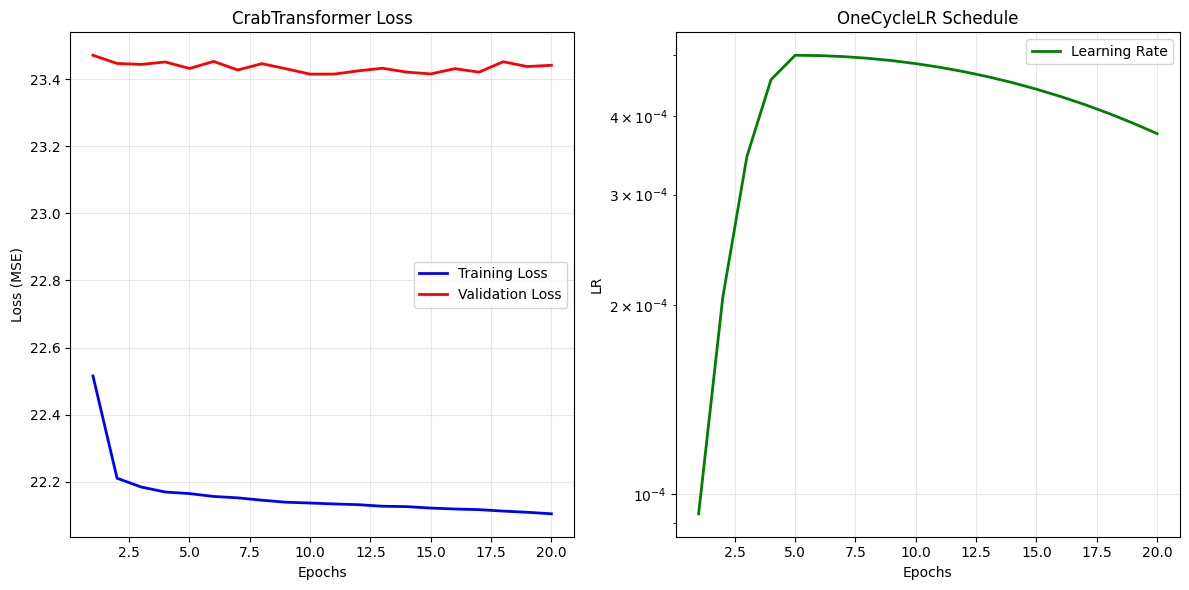

In [ ]:
## stop! is the data from github updated in the google drive?


import torch.optim as optim
from torch.optim.lr_scheduler import LambdaLR, OneCycleLR
import json

def train_model_max_scaled():
    print("--- Initializing Data ---")

    print('Data generated from these parameters:')
    params_path = os.path.join(REPO_DIR, 'data/dummy/output/gmrf_params.json')
    params = json.load(open(params_path))
    print(json.dumps(params, indent=2))

    checkpoint_dir = os.path.join(DATA_PATH, "checkpoints")



    train_loader, val_loader, test_loader = get_dataloaders(
      batch_size=8, memory_years=5,
      train_years=22, val_years=5, test_years=3,
      transform='log'
    )

    # 2. Setup Model
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = CrabTransformer(
        grid_size=50, patch_size=5, in_channels=11,
        embed_dim=64, num_heads=4, num_layers=3, d_ff=256, dropout=0.3
    ).to(device)

    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Trainable parameters: {n_params:,}")


    all_targets = []
    for _, targets, _, _ in train_loader:
        all_targets.append(targets.mean().item())
    mean_target = sum(all_targets) / len(all_targets)


    bias_init = mean_target
    nn.init.constant_(model.decoder.conv_out.bias, bias_init)
    print(f"Decoder bias set to {bias_init:.3f} → expm1 = {math.expm1(bias_init):.3f}")

    #bias_init = math.log(math.exp(mean_target) - 1)
    # Overwrite the model's decoder bias
    #nn.init.constant_(model.decoder.conv_out.bias, bias_init)
    #print(f"Decoder bias was now set to {bias_init:.3f} → softplus = {mean_target:.3f}")

    # 3. Setup Tweedie Loss (Works because data is now positive 0-1)
    # Power 1.5 is standard for compound Poisson-Gamma (Fisheries data)
    criterion = TweedieLoss(power=1.5)
    #criterion = nn.MSELoss()

    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

    # 4. Linear Warmup + Plateau
    # This prevents the "Identity Trap" in early epochs -- which I was seeing
    def warmup_lambda(epoch):
        if epoch < 5:
            return (epoch + 1) / 5  # Ramp up: 0.2, 0.4, 0.6, 0.8, 1.0
        return 1.0

    #scheduler_warmup = LambdaLR(optimizer, lr_lambda=warmup_lambda)
    #scheduler_plateau = torch.optim.lr_scheduler.ReduceLROnPlateau(
    #    optimizer, mode='min', factor=0.5, patience=10
    #)

    scheduler = OneCycleLR(
        optimizer,
        max_lr=5e-4,
        epochs=50,
        steps_per_epoch=len(train_loader),
        pct_start=0.1,          # 10% warmup
        anneal_strategy="cos",
        div_factor=10,          # initial_lr = max_lr / 10
        final_div_factor=100,   # final_lr  = max_lr / 1000
    )

    # Training Loop
    best_val_loss = float('inf')
    epochs = 50
    early_stop_patience = 10
    patience_counter = 0
    history = {"train_loss": [], "val_loss": [], "lr": []}

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for inputs, targets, temporal_mask, year_idx in train_loader:
            inputs, targets, year_idx = inputs.to(device), targets.to(device), year_idx.to(device)

            optimizer.zero_grad()

            # --- MODEL FORWARD ---
            # Ensure your model output has a sigmoid/softplus!
            outputs = model(inputs, year_idx)
            pred_original = torch.expm1(outputs).clamp(min=1e-6)
            targets_original = torch.expm1(targets).clamp(min=1e-6)
            loss = criterion(pred_original, targets_original)

            # Tweedie requires positive targets. Our Max Scaling guarantees this.
            #loss = criterion(outputs, targets)

            loss.backward()

            # Clip gradients (Safety)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            scheduler.step()
            total_loss += loss.item()

            # --- Negative prediction diagnostic ---
            with torch.no_grad():
                raw_output = outputs.detach()
                n_negative = (raw_output < 0).sum().item()
                n_total = raw_output.numel()
                if n_negative > 0:
                    neg_pct = 100.0 * n_negative / n_total
                    neg_mean = raw_output[raw_output < 0].mean().item()
                    if neg_pct > 5:  # only print if it's significant
                        print(f"  ⚠ {neg_pct:.1f}% negative raw outputs "
                              f"(mean={neg_mean:.3f}, clamped to 1e-6)")

        avg_train = total_loss / len(train_loader)

        # ---- Validate ----
        model.eval()
        total_val_loss = 0.0

        with torch.no_grad():
            for inputs, targets, temporal_mask, year_idx in val_loader:
                inputs  = inputs.to(device)
                targets = targets.to(device)
                year_idx = year_idx.to(device)

                outputs = model(inputs, year_idx)
                pred_original = torch.expm1(outputs).clamp(min=1e-6)
                targets_original = torch.expm1(targets).clamp(min=1e-6)
                total_val_loss += criterion(pred_original, targets_original).item()

        avg_val = total_val_loss / len(val_loader)


        model.eval()
        with torch.no_grad():# Quick check on one training batch
          sample_inputs, sample_targets, _, sample_yr = next(iter(train_loader))
          sample_out = model(sample_inputs.to(device), sample_yr.to(device))
          neg_frac = (sample_out < 0).float().mean().item()
          pred_mean = sample_out.mean().item()
          pred_std = sample_out.std().item()
          print(f"  Raw output stats: mean={pred_mean:.3f}, "
                f"std={pred_std:.3f}, neg%={100*neg_frac:.1f}%")

        # ---- Bookkeeping ----
        current_lr = optimizer.param_groups[0]["lr"]
        history["train_loss"].append(avg_train)
        history["val_loss"].append(avg_val)
        history["lr"].append(current_lr)

        improved = ""
        if avg_val < best_val_loss:
            best_val_loss = avg_val
            patience_counter = 0
            torch.save(model.state_dict(), os.path.join(checkpoint_dir, "best_model.pt"))
            improved = " ✓ Saved"
        else:
            patience_counter += 1

        print(
            f"Epoch {epoch+1:3d} | "
            f"Train: {avg_train:.4f} | Val: {avg_val:.4f} | "
            f"LR: {current_lr:.2e} | "
            f"Patience: {patience_counter}/{early_stop_patience}{improved}"
        )

        # ---- Early stopping ----
        if patience_counter >= early_stop_patience:
            print(f"\nEarly stopping at epoch {epoch+1} (best val: {best_val_loss:.4f})")
            break

    # ==================================================================
    # 5. LOAD BEST MODEL & EVALUATE ON TEST
    # ==================================================================
    print("\n--- Evaluating best model on test set ---")
    model.load_state_dict(torch.load(os.path.join(checkpoint_dir, "best_model.pt"),
                                     map_location=device))
    model.eval()
    total_test_loss = 0.0

    with torch.no_grad():
        for inputs, targets, temporal_mask, year_idx in test_loader:
            inputs  = inputs.to(device)
            targets = targets.to(device)
            year_idx = year_idx.to(device)

            outputs = model(inputs, year_idx)
            pred_original = torch.expm1(outputs).clamp(min=1e-6)
            targets_original = torch.expm1(targets).clamp(min=1e-6)
            total_test_loss += criterion(pred_original, targets_original).item()

    avg_test = total_test_loss / len(test_loader)
    print(f"Test Loss: {avg_test:.4f}")

    # Save training history
    with open(os.path.join(checkpoint_dir, "training_history.json"), "w") as f:
        json.dump(history, f)

    epochs_range = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 6))

    # Loss Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history["train_loss"], label='Training Loss', color='blue', lw=2)
    plt.plot(epochs_range, history["val_loss"], label='Validation Loss', color='red', lw=2)
    plt.title('CrabTransformer Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (Tweedie)')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Learning Rate Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history["lr"], label='Learning Rate', color='green', lw=2)
    plt.title('OneCycleLR Schedule')
    plt.xlabel('Epochs')
    plt.ylabel('LR')
    plt.yscale('log') # Log scale helps see the annealing
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plot_path = os.path.join(checkpoint_dir, "training_curves.png")
    plt.savefig(plot_path)
    print(f"Plot saved to: {plot_path}")
    plt.show()

    return model, history

if __name__ == "__main__":
    model, history = train_model_max_scaled()

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import os
from torch.utils.data import DataLoader
from models.model import CrabTransformer
# Assuming your CrabDataset class is in a file named dataset.py
from data.data_helper import CrabDataset, get_dataloaders

def test_overfit_on_real_data():
    """
    Diagnostic: Can the model overfit to ONE actual GMRF sample?
    Uses MSE loss to isolate architecture performance.
    """
    print("=" * 70)
    print("🔬 GMRF DATA OVERFITTING TEST (MSE Loss)")
    print("=" * 70)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    DATA_PATH = "/content/drive/MyDrive/Teleconnection_ViT"

    # 1. Load data using your actual Dataset class logic
    print(f"\n📂 Loading GMRF data from {DATA_PATH}...")

    # Matching your training loop's n_years=22
    train_loader, val_loader, test_loader = get_dataloaders(
      batch_size=8, memory_years=5,
      train_years=22, val_years=5, test_years=3,
      transform='log'
    )


    # 2. Setup Model
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = CrabTransformer(
        grid_size=50, patch_size=5, in_channels=11,
        embed_dim=64, num_heads=4, num_layers=3, d_ff=256, dropout=0
    ).to(device)

    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Trainable parameters: {n_params:,}")


    all_targets = []
    for _, targets, _, _ in train_loader:
        all_targets.append(targets.mean().item())
    mean_target = sum(all_targets) / len(all_targets)
    bias_init = math.log(math.exp(mean_target) - 1)
    # Overwrite the model's decoder bias
    nn.init.constant_(model.decoder.conv_out.bias, bias_init)
    print(f"Decoder bias was now set to {bias_init:.3f} → softplus = {mean_target:.3f}")

    # Grab ONE sample to overfit on
    inputs, targets, temporal_mask, year_idx = next(iter(train_loader))
    # Take just the first sample from the batch
    inputs = inputs[:1].to(device)
    targets = targets[:1].to(device)
    year_idx = year_idx[:1].to(device)

    # 3. Optimization Setup
    #criterion = nn.MSELoss()
    criterion = TweedieLoss(power=1.1)
    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4) # Higher LR for fast overfitting

    print("\n🚀 Training for 1000 epochs on a single sample...")
    model.train()

    for epoch in range(1000):
        optimizer.zero_grad()

        # Model Forward
        output = model(inputs, year_idx)

        loss = criterion(output, targets)

        loss.backward()

        # Gradient clipping as used in your real loop
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        if (epoch + 1) % 200 == 0:
            print(f"   Epoch {epoch+1:4d} | Loss: {loss.item():.8f}")

    # 4. Final Verification
    model.eval()
    with torch.no_grad():
        final_output = model(inputs, year_idx)
        pred_np = final_output.cpu().numpy().flatten()
        targ_np = targets.cpu().numpy().flatten()

        corr = np.corrcoef(pred_np, targ_np)[0, 1]

    print("\n" + "=" * 70)
    print("🏁 FINAL DIAGNOSTIC VERDICT:")
    print("=" * 70)

    if corr > 0.98:
        print(f"✅ SUCCESS! Final Correlation: {corr:.4f}")
        print("   The architecture CAN learn your GMRF spatial patterns.")
        print("   If real training fails, focus on Tweedie Power or Warmup.")
    else:
        print(f"❌ FAILURE. Final Correlation: {corr:.4f}")
        print("   The model cannot overfit a single sample.")
        print("   Check if model output has a Sigmoid/Softplus (Tweedie likes positive outputs).")

if __name__ == "__main__":
    test_overfit_on_real_data()

🔬 GMRF DATA OVERFITTING TEST (MSE Loss)

📂 Loading GMRF data from /content/drive/MyDrive/Teleconnection_ViT...
Detected 100 bootstrap samples
Loaded 100 bootstrap samples, 22 years each
Applying Log-Scaling: x_scaled = log(1 + x)

Extracting historical context from training data for validation...
Loaded 100 bootstrap samples, 5 years each
  Using 5 years of historical data from previous split
Applying Log-Scaling: x_scaled = log(1 + x)

Extracting historical context from validation data for test...
Loaded 100 bootstrap samples, 3 years each
  Using 5 years of historical data from previous split
Applying Log-Scaling: x_scaled = log(1 + x)

Data shapes:
(100, 5, 50, 50) (100, 5, 50, 50)
(100, 5, 50, 50) (100, 5, 50, 50) 

Sinusoidal temporal encoding initialized:
  Pre-computed years: 0-49
  Can dynamically compute beyond year 50 ✓
Initializing model weights...
✓ Applying Bias Initialization Surgery to Decoder (-1.0)
✓ Weight initialization complete
Trainable parameters: 229,041
Decoder 

--- 1. Setup & Normalization ---
Max Constants (for un-scaling) | Spawner: 6064870.75 | Recruit: 5458402.72
--- 2. Creating Full 30-Year Dataset ---
Detected 100 bootstrap samples
Loaded 100 bootstrap samples, 22 years each
Applying Log-Scaling: x_scaled = log(1 + x)

Extracting historical context from training data for validation...
Loaded 100 bootstrap samples, 5 years each
  Using 5 years of historical data from previous split
Applying Log-Scaling: x_scaled = log(1 + x)

Extracting historical context from validation data for test...
Loaded 100 bootstrap samples, 3 years each
  Using 5 years of historical data from previous split
Applying Log-Scaling: x_scaled = log(1 + x)

Data shapes:
(100, 5, 50, 50) (100, 5, 50, 50)
(100, 5, 50, 50) (100, 5, 50, 50) 

--- 2. Loading Model ---
Sinusoidal temporal encoding initialized:
  Pre-computed years: 0-49
  Can dynamically compute beyond year 50 ✓
Initializing model weights...
✓ Applying Bias Initialization Surgery to Decoder (-1.0)
✓ Weight

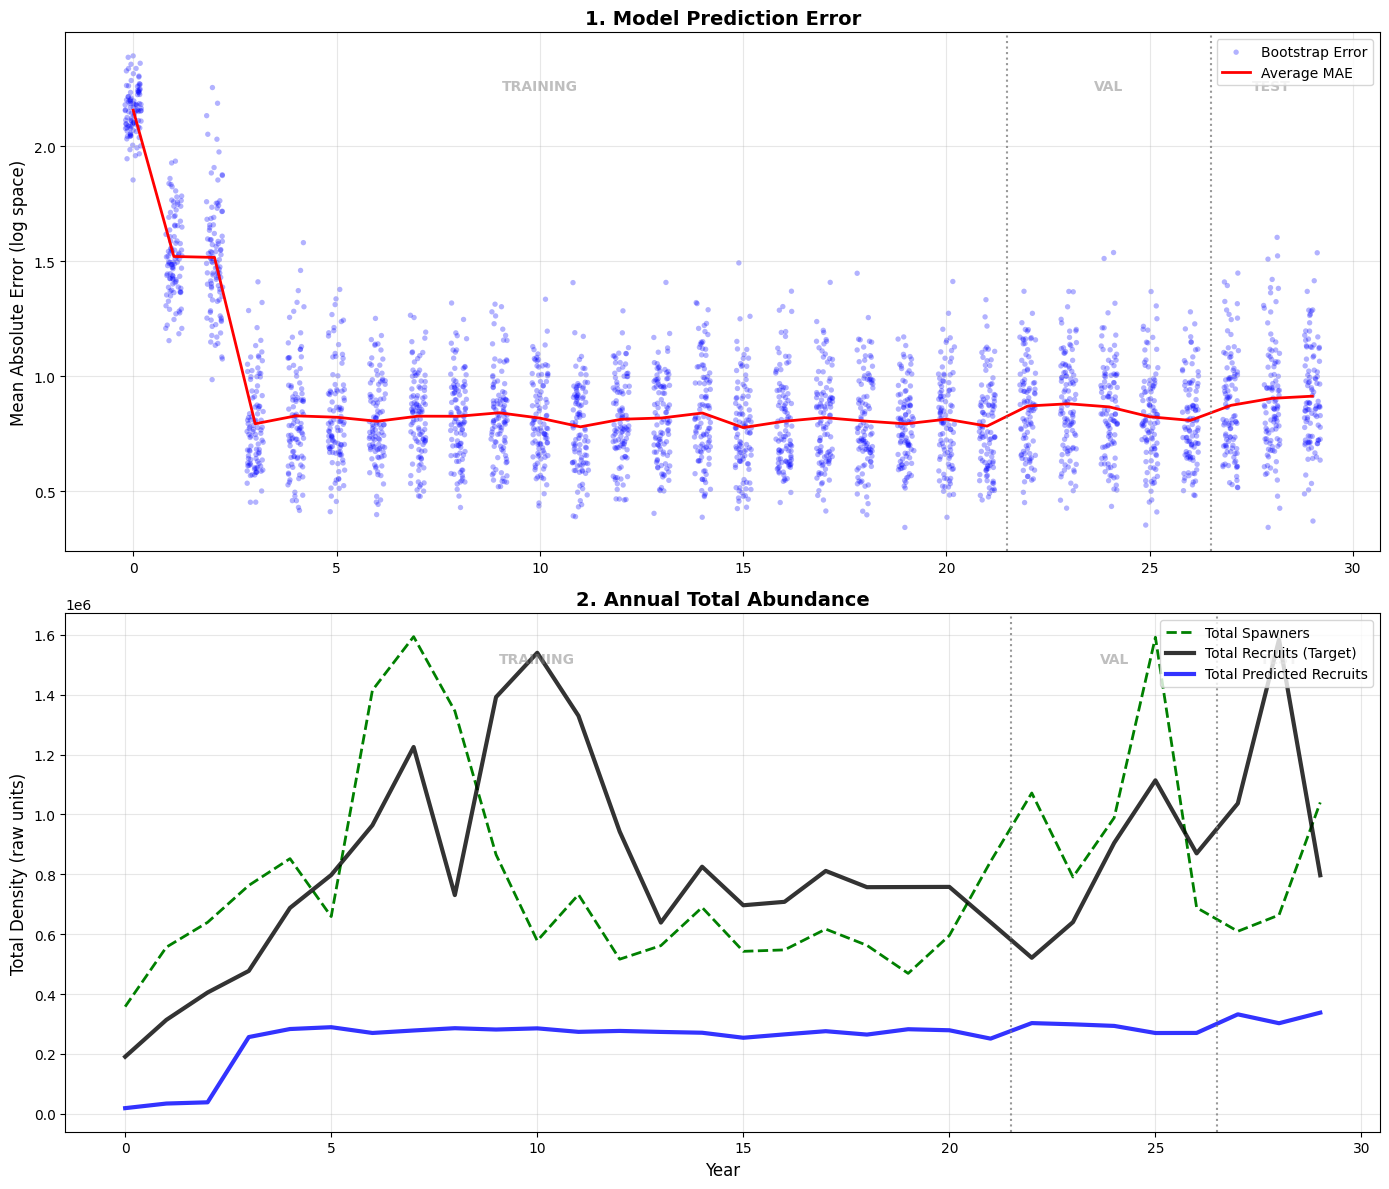

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import sys
import os
import pandas as pd
from torch.utils.data import DataLoader

# --- CONFIGURATION ---
REPO_DIR = '/content/Teleconnections-ViT'
DRIVE_DIR = "/content/drive/MyDrive/Teleconnection_ViT"
DATA_PATH = DRIVE_DIR
RAW_DATA_PATH = os.path.join(REPO_DIR, "data/dummy/output")
CHECKPOINT_PATH = os.path.join(DRIVE_DIR, "checkpoints/best_model.pt")

if REPO_DIR not in sys.path: sys.path.append(REPO_DIR)
try:
    from models.model import CrabTransformer
    from data.data_helper import CrabDataset, get_dataloaders
except ImportError:
    print("❌ Critical Error: Could not import model.py or CrabDataset")
    sys.exit(1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def analyze_full_history_abundance():
    print("--- 1. Setup & Normalization ---")
    # Load training data to get MAX constants for DENORMALIZATION
    train_spawners = np.load(os.path.join(DATA_PATH, "train_spawners.npy"))
    train_recruits = np.load(os.path.join(DATA_PATH, "train_recruits.npy"))
    SPAWN_MAX = np.max(train_spawners) + 1e-6
    RECRUIT_MAX = np.max(train_recruits) + 1e-6
    print(f"Max Constants (for un-scaling) | Spawner: {SPAWN_MAX:.2f} | Recruit: {RECRUIT_MAX:.2f}")

    print("--- 2. Creating Full 30-Year Dataset ---")
    # Load RAW data (100 bootstraps * 30 years)
    train_loader, val_loader, test_loader = get_dataloaders(
    batch_size=8, memory_years=5,
    train_years=22, val_years=5, test_years=3,
    transform='log'
    )

    # Override train loader to not shuffle for evaluation
    train_loader = DataLoader(train_loader.dataset, batch_size=12, shuffle=False)

    print("--- 2. Loading Model ---")
    model = CrabTransformer(
        grid_size=50, patch_size=5, in_channels=11,
        embed_dim=64, num_heads=4, num_layers=3, d_ff=256, dropout=0
    ).to(device)


    if os.path.exists(CHECKPOINT_PATH):
        model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
        print("✓ Weights loaded.")
    else:
        print("⚠️ Checkpoint not found! Using random weights.")

    model.eval()

    scatter_years = []
    scatter_mae = []
    abundance_records = []

    print("--- 3. Running Inference ---")

    # Run each split with its proper historical context
    loaders = [
        ("TRAIN", train_loader, 0),      # year offset 0
        ("VAL",   val_loader,   22),      # year offset = train_years
        ("TEST",  test_loader,  27),      # year offset = train_years + val_years
    ]

    for phase, loader, year_offset in loaders:
        with torch.no_grad():
            for inputs, targets, temporal_mask, year_indices in loader:
                inputs, targets = inputs.to(device), targets.to(device)
                temporal_mask = temporal_mask.to(device)
                year_indices = year_indices.to(device)

                outputs = model(inputs, year_indices, temporal_mask=temporal_mask)

                preds_np = outputs.cpu().numpy()
                targets_np = targets.cpu().numpy()
                inputs_np = inputs.cpu().numpy()
                years_np = year_indices.cpu().numpy()

                for i in range(preds_np.shape[0]):
                    # Absolute year across the full 30-year timeline
                    year_absolute = years_np[i] + year_offset

                    pred_log = preds_np[i, 0]
                    target_log = targets_np[i, 0]
                    input_log = inputs_np[i, 0]

                    mae = np.mean(np.abs(pred_log - target_log))
                    scatter_years.append(year_absolute)
                    scatter_mae.append(mae)

                    pred_real = np.expm1(pred_log)
                    target_real = np.expm1(target_log)
                    input_real = np.expm1(input_log)

                    abundance_records.append({
                        'year': year_absolute,
                        'phase': phase,
                        'total_spawner': np.sum(input_real),
                        'total_recruit': np.sum(target_real),
                        'total_pred': np.sum(pred_real),
                    })

        print(f"  ✓ {phase} done")

    # --- VISUALIZATION (same as before) ---
    print("--- 4. Generating Plots ---")

    df = pd.DataFrame(abundance_records)
    df_annual = df.groupby('year').mean(numeric_only=True).reset_index()

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

    jitter = np.random.uniform(-0.2, 0.2, size=len(scatter_years))
    ax1.scatter(np.array(scatter_years) + jitter, scatter_mae,
                alpha=0.3, s=15, c='blue', edgecolors='none', label='Bootstrap Error')

    unique_years = sorted(list(set(scatter_years)))
    avg_mae = [np.mean([e for y, e in zip(scatter_years, scatter_mae) if y==uy]) for uy in unique_years]
    ax1.plot(unique_years, avg_mae, 'r-', linewidth=2, label='Average MAE')
    add_regions(ax1)
    ax1.set_title("1. Model Prediction Error", fontsize=14, fontweight='bold')
    ax1.set_ylabel("Mean Absolute Error (log space)", fontsize=12)
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)

    ax2.plot(df_annual['year'], df_annual['total_spawner'], 'g--', linewidth=2, label='Total Spawners')
    ax2.plot(df_annual['year'], df_annual['total_recruit'], 'k-', linewidth=3, alpha=0.8, label='Total Recruits (Target)')
    ax2.plot(df_annual['year'], df_annual['total_pred'], 'b-', linewidth=3, alpha=0.8, label='Total Predicted Recruits')
    add_regions(ax2)
    ax2.set_title("2. Annual Total Abundance", fontsize=14, fontweight='bold')
    ax2.set_xlabel("Year", fontsize=12)
    ax2.set_ylabel("Total Density (raw units)", fontsize=12)
    ax2.legend(loc='upper right')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def add_regions(ax):
    """Helper to draw Train/Val/Test regions"""
    ymin, ymax = ax.get_ylim()
    ax.axvline(21.5, color='gray', linestyle=':', alpha=0.8)
    ax.axvline(26.5, color='gray', linestyle=':', alpha=0.8)

    # Labels
    ax.text(10, ymax*0.9, "TRAINING", ha='center', color='gray', fontweight='bold', alpha=0.5)
    ax.text(24, ymax*0.9, "VAL", ha='center', color='gray', fontweight='bold', alpha=0.5)
    ax.text(28, ymax*0.9, "TEST", ha='center', color='gray', fontweight='bold', alpha=0.5)

if __name__ == "__main__":
    analyze_full_history_abundance()

--- Building datasets with proper historical context ---
Detected 100 bootstrap samples
Loaded 100 bootstrap samples, 22 years each
Applying Log-Scaling: x_scaled = log(1 + x)

Extracting historical context from training data for validation...
Loaded 100 bootstrap samples, 5 years each
  Using 5 years of historical data from previous split
Applying Log-Scaling: x_scaled = log(1 + x)

Extracting historical context from validation data for test...
Loaded 100 bootstrap samples, 3 years each
  Using 5 years of historical data from previous split
Applying Log-Scaling: x_scaled = log(1 + x)

Data shapes:
(100, 5, 50, 50) (100, 5, 50, 50)
(100, 5, 50, 50) (100, 5, 50, 50) 

Sinusoidal temporal encoding initialized:
  Pre-computed years: 0-49
  Can dynamically compute beyond year 50 ✓
Initializing model weights...
✓ Applying Bias Initialization Surgery to Decoder (-1.0)
✓ Weight initialization complete
✓ Checkpoint loaded
--- Running inference ---
  ✓ TRAIN: 2200 samples
  ✓ VAL: 500 samples
 

/tmp/ipython-input-3523084644.py:275: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.01, 0.92, 0.97])


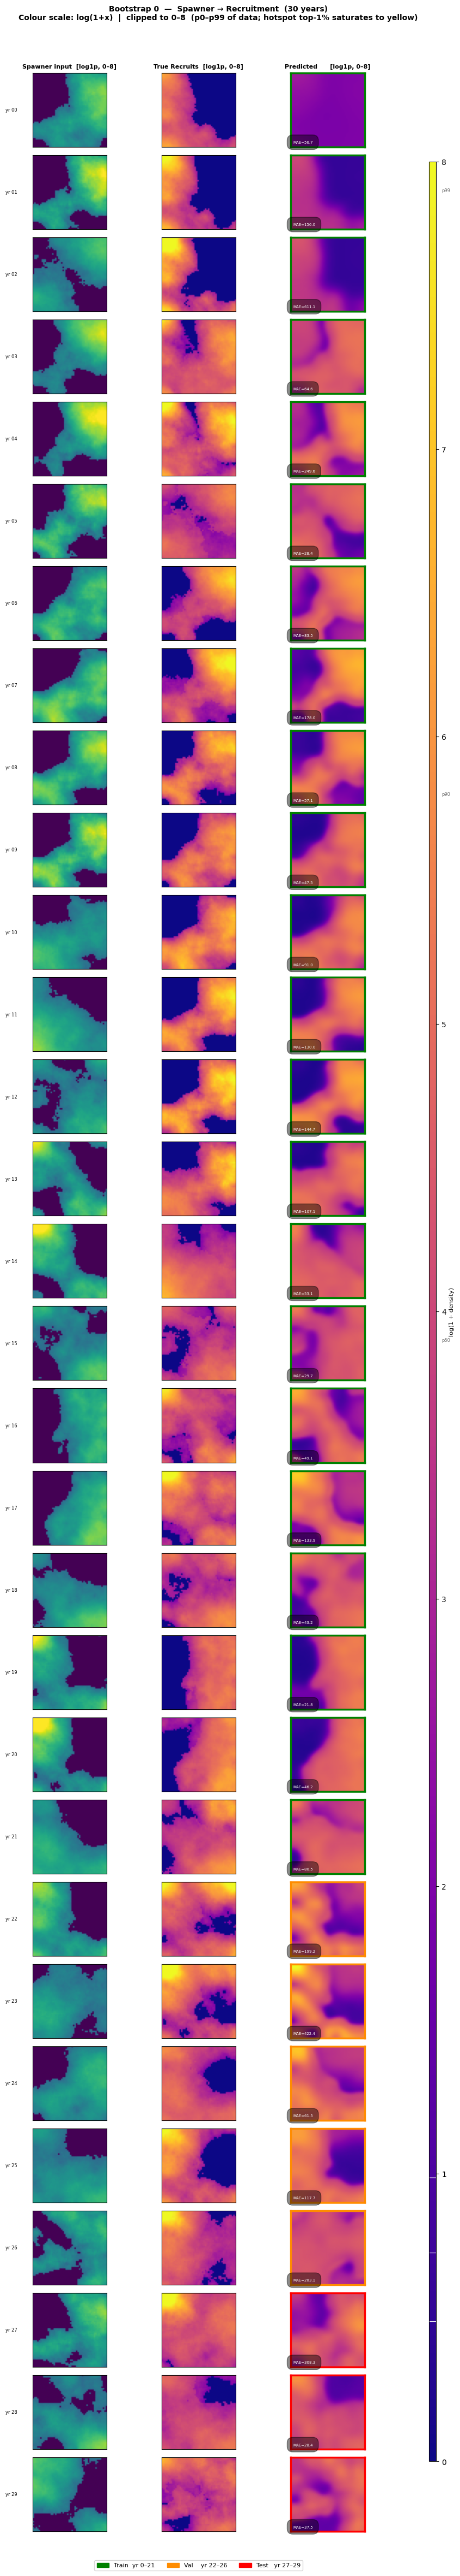

✓  Saved → /content/drive/MyDrive/Teleconnection_ViT/analysis/final_evaluation/spatial_trajectory_boot0.png


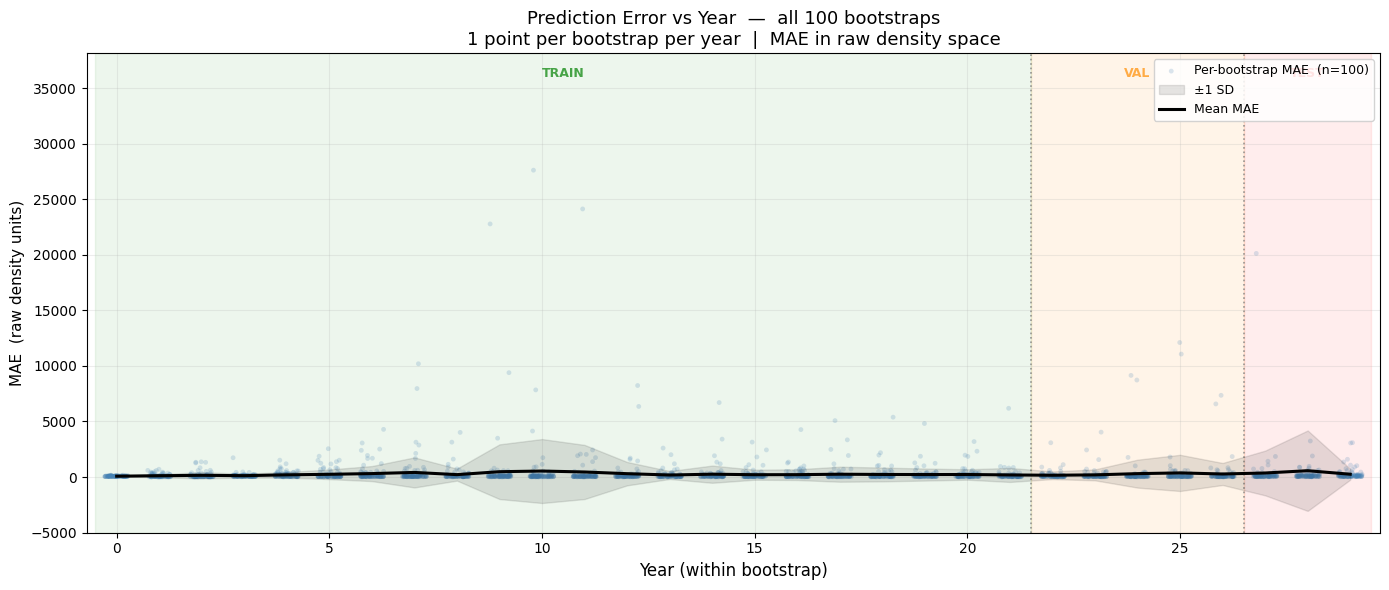

✓  Saved → /content/drive/MyDrive/Teleconnection_ViT/analysis/final_evaluation/error_scatter.png

Year summary (MAE in raw density space):
 Year  Phase      Mean MAE          SD
    0  TRAIN         76.04       29.49
    1  TRAIN        118.96      142.92
    2  TRAIN        154.88      278.07
    3  TRAIN        124.06      180.85
    4  TRAIN        198.20      246.58
    5  TRAIN        246.67      434.04
    6  TRAIN        311.49      677.32
    7  TRAIN        415.16     1353.04
    8  TRAIN        217.68      539.89
    9  TRAIN        480.96     2461.63
   10  TRAIN        540.39     2878.64
   11  TRAIN        455.34     2435.73
   12  TRAIN        303.34     1052.13
   13  TRAIN        182.44      358.84
   14  TRAIN        256.80      774.70
   15  TRAIN        209.34      452.31
   16  TRAIN        214.69      483.26
   17  TRAIN        254.21      675.73
   18  TRAIN        232.11      620.78
   19  TRAIN        224.16      542.51
   20  TRAIN        229.04      469.43
   

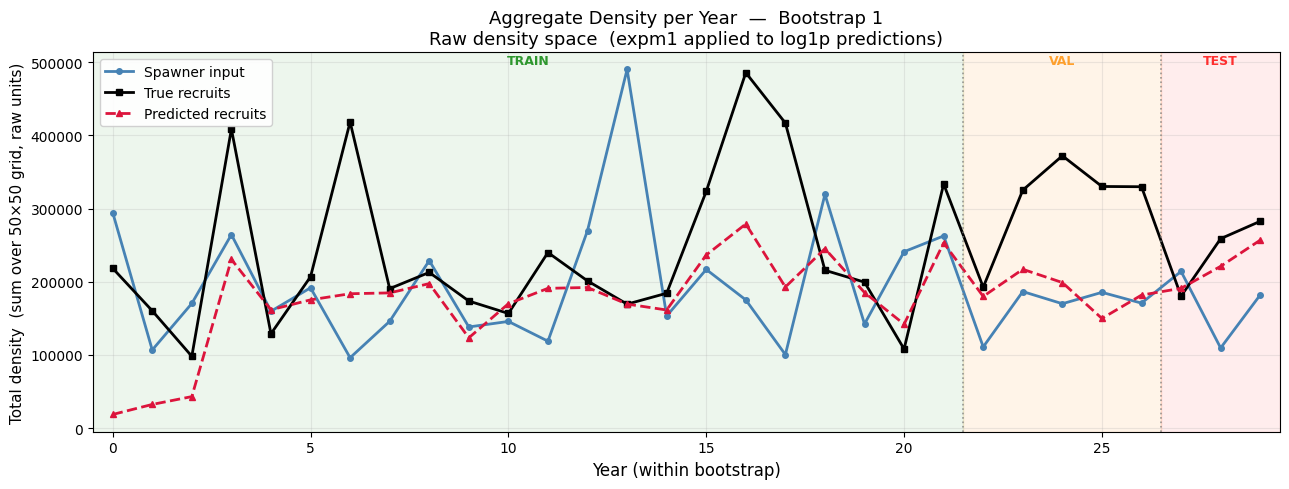

✓  Saved → /content/drive/MyDrive/Teleconnection_ViT/analysis/final_evaluation/aggregate_timeseries_boot1.png

Aggregate density summary — Bootstrap 1:
 Year  Phase         Spawner        True Rec        Pred Rec
    0  TRAIN        294628.2        218451.1         18772.8
    1  TRAIN        106870.7        160373.6         32475.3
    2  TRAIN        170407.4         98210.0         43177.6
    3  TRAIN        264412.8        408689.2        230574.7
    4  TRAIN        159778.3        129044.5        161767.9
    5  TRAIN        191793.7        206862.9        175340.3
    6  TRAIN         96254.0        418277.0        183681.5
    7  TRAIN        146000.8        190640.2        184835.8
    8  TRAIN        228925.2        212822.0        197501.1
    9  TRAIN        138292.9        173722.8        123466.3
   10  TRAIN        145858.6        156733.7        170012.6
   11  TRAIN        118884.5        239975.2        191058.9
   12  TRAIN        269942.9        201198.4        192

In [ ]:
"""
evaluate_spatial_trajectory.py  (updated colormap)
----------------------------------------------------
Key change from previous version:
  • Plots are shown in log1p space  (NOT inverted back to raw)
  • Fixed colour limits:
      recruits/predictions : vmin=0, vmax=8.0   (covers p0–p99 in log space)
      spawners             : vmin=0, vmax=8.0
  • This stops the rare extreme hotspot cells (max ~15.6) from collapsing
    the rest of the colormap to a nearly-uniform dark band.

Transform assumption: log(1 + x) — NO max-scaling.
"""

import os
import sys
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from torch.utils.data import DataLoader
from scipy.stats import spearmanr

# ---------------------------------------------------------------------------
# CONFIGURATION
# ---------------------------------------------------------------------------
REPO_DIR        = "/content/Teleconnections-ViT"
DRIVE_DIR       = "/content/drive/MyDrive/Teleconnection_ViT"
DATA_PATH       = DRIVE_DIR
RAW_DATA_PATH   = os.path.join(REPO_DIR, "data/dummy/output")
CHECKPOINT_PATH = os.path.join(DRIVE_DIR, "checkpoints/best_model.pt")
SAVE_DIR        = os.path.join(DRIVE_DIR, "analysis/final_evaluation")
os.makedirs(SAVE_DIR, exist_ok=True)

N_YEARS   = 30
N_HIST    = 5
TRAIN_END = 22
VAL_END   = 27

# ---  Colour limits in log1p space  ---
# From diagnostics:
#   p50  recruits log1p ≈ 3.9   p90 ≈ 5.8   p99 ≈ 7.9   max ≈ 15.5
# Setting vmax=8 shows 99% of cells with full colour range.
# The top 1% of extreme hotspot cells saturates to yellow — intentional.
VMAX_RC = 8.0    # recruits + predictions
VMAX_SP = 8.0    # spawner input (same scale for easy comparison)
VMIN    = 0.0    # zero cells map to black in plasma/viridis

if REPO_DIR not in sys.path:
    sys.path.append(REPO_DIR)
try:
    from models.model import CrabTransformer
    from data.data_helper import CrabDataset
except ImportError:
    print("❌ Could not import CrabTransformer or CrabDataset — check REPO_DIR")
    raise

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ---------------------------------------------------------------------------
# HELPERS
# ---------------------------------------------------------------------------

def phase_of(year):
    if year < TRAIN_END:
        return "TRAIN", "green"
    elif year < VAL_END:
        return "VAL", "darkorange"
    else:
        return "TEST", "red"


def add_phase_regions(ax):
    ax.axvline(TRAIN_END - 0.5, color="grey", linestyle=":", lw=1.2, alpha=0.8)
    ax.axvline(VAL_END   - 0.5, color="grey", linestyle=":", lw=1.2, alpha=0.8)
    trans = ax.get_xaxis_transform()
    ax.text(TRAIN_END / 2 - 0.5,              0.95, "TRAIN", transform=trans,
            ha="center", fontsize=9, color="green",      fontweight="bold", alpha=0.7)
    ax.text((TRAIN_END + VAL_END) / 2 - 0.5,  0.95, "VAL",   transform=trans,
            ha="center", fontsize=9, color="darkorange", fontweight="bold", alpha=0.7)
    ax.text((VAL_END + N_YEARS) / 2 - 0.5,    0.95, "TEST",  transform=trans,
            ha="center", fontsize=9, color="red",         fontweight="bold", alpha=0.7)


# ---------------------------------------------------------------------------
# LOAD MODEL + RUN INFERENCE
# ---------------------------------------------------------------------------

def load_model():
    model = CrabTransformer(
        grid_size=50, patch_size=5, in_channels=11,
        embed_dim=64, num_heads=4, num_layers=3, d_ff=256, dropout=0.0,
    ).to(device)
    if os.path.exists(CHECKPOINT_PATH):
        ckpt  = torch.load(CHECKPOINT_PATH, map_location=device)
        state = ckpt.get("model_state_dict", ckpt)
        model.load_state_dict(state)
        print("✓ Checkpoint loaded")
    else:
        print("⚠️  No checkpoint found — using random weights")
    model.eval()
    return model


def run_inference():
    print("--- Building datasets with proper historical context ---")
    train_loader, val_loader, test_loader = get_dataloaders(
        batch_size=8, memory_years=5,
        train_years=22, val_years=5, test_years=3,
        transform='log'
    )
    train_loader = DataLoader(train_loader.dataset, batch_size=12, shuffle=False)
    model = load_model()

    records = []

    loaders = [
        ("TRAIN", train_loader, 0),
        ("VAL",   val_loader,   22),
        ("TEST",  test_loader,  27),
    ]

    print("--- Running inference ---")
    with torch.no_grad():
        for phase, loader, year_offset in loaders:
            sample_count = 0
            for inputs, targets, mask, year_indices in loader:
                inputs = inputs.to(device)
                targets = targets.to(device)
                year_indices = year_indices.to(device)

                outputs = model(inputs, year_indices)

                preds_np   = outputs.cpu().numpy()
                targets_np = targets.cpu().numpy()
                inputs_np  = inputs.cpu().numpy()
                years_np   = year_indices.cpu().numpy()

                for i in range(preds_np.shape[0]):
                    year_absolute = int(years_np[i]) + year_offset
                    bootstrap = sample_count // loader.dataset.n_years
                    sample_count += 1

                    pred_log    = preds_np[i, 0]   if preds_np.ndim   == 4 else preds_np[i]
                    target_log  = targets_np[i, 0] if targets_np.ndim == 4 else targets_np[i]
                    spawner_log = inputs_np[i, 0]  if inputs_np.ndim  == 4 else inputs_np[i]

                    pred_raw   = np.expm1(pred_log)
                    target_raw = np.expm1(target_log)

                    # Flatten the 50x50 grids to 1D arrays for correlation
                    p_flat = pred_log.flatten()
                    t_flat = target_log.flatten()

                    # Calculate Spearman Correlation
                    # We use a small handle for cases with zero variance (rare but possible)
                    corr, _ = spearmanr(p_flat, t_flat)
                    if np.isnan(corr): corr = 0.0

                    records.append({
                        "bootstrap":   bootstrap,
                        "year":        year_absolute,
                        "phase":       phase,
                        "pred_log":    pred_log,
                        "target_log":  target_log,
                        "spawner_log": spawner_log,
                        "mae_log":     float(np.mean(np.abs(pred_log - target_log))),
                        "mae_raw":     float(np.mean(np.abs(pred_raw - target_raw))),
                        "spearman":    float(corr)
                    })

            print(f"  ✓ {phase}: {sample_count} samples")

    print(f"✓  {len(records)} total records")
    return records


# ---------------------------------------------------------------------------
# PLOT 1: SPATIAL TRAJECTORY  (one bootstrap, all 30 years)
# ---------------------------------------------------------------------------

def plot_spatial_trajectory(records, bootstrap_idx=0):
    """
    30 rows × 3 columns, all in log1p space with fixed colour limits.
    Border colour = green/orange/red for train/val/test.
    Per-cell MAE annotated on each prediction panel.
    """
    boot_rows = sorted(
        [r for r in records if r["bootstrap"] == bootstrap_idx],
        key=lambda r: r["year"],
    )
    if not boot_rows:
        print(f"Bootstrap {bootstrap_idx} not found.")
        return

    n_rows = len(boot_rows)
    fig, axes = plt.subplots(n_rows, 3, figsize=(9, n_rows * 1.6))
    fig.suptitle(
        f"Bootstrap {bootstrap_idx}  —  Spawner → Recruitment  ({n_rows} years)\n"
        f"Colour scale: log(1+x)  |  clipped to 0–{VMAX_RC:.0f}  "
        f"(p0–p99 of data; hotspot top-1% saturates to yellow)",
        fontsize=10, fontweight="bold",
    )

    col_titles = [
        f"Spawner input  [log1p, 0–{VMAX_SP:.0f}]",
        f"True Recruits  [log1p, 0–{VMAX_RC:.0f}]",
        f"Predicted      [log1p, 0–{VMAX_RC:.0f}]",
    ]
    for j, title in enumerate(col_titles):
        axes[0, j].set_title(title, fontsize=8, fontweight="bold")

    for row_idx, r in enumerate(boot_rows):
        _, border_color = phase_of(r["year"])

        # col 0 — spawner
        axes[row_idx, 0].imshow(
            r["spawner_log"], cmap="viridis",
            vmin=VMIN, vmax=VMAX_SP, origin="lower", aspect="equal",
        )
        axes[row_idx, 0].set_ylabel(
            f"yr {r['year']:02d}",
            fontsize=6, rotation=0, labelpad=28, va="center",
        )

        # col 1 — true recruits
        axes[row_idx, 1].imshow(
            r["target_log"], cmap="plasma",
            vmin=VMIN, vmax=VMAX_RC, origin="lower", aspect="equal",
        )

        # col 2 — prediction + coloured border + MAE label
        im = axes[row_idx, 2].imshow(
            r["pred_log"], cmap="plasma",
            vmin=VMIN, vmax=VMAX_RC, origin="lower", aspect="equal",
        )
        for spine in axes[row_idx, 2].spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(2.5)
            spine.set_visible(True)

        axes[row_idx, 2].text(
            0.03, 0.04, f"MAE={r['mae_raw']:.1f}",
            transform=axes[row_idx, 2].transAxes,
            fontsize=5, color="white", va="bottom",
            bbox=dict(facecolor="black", alpha=0.45, pad=1.5, boxstyle="round"),
        )

        for j in range(3):
            axes[row_idx, j].set_xticks([])
            axes[row_idx, j].set_yticks([])

    # Shared recruit colourbar with percentile markers
    cbar_ax = fig.add_axes([0.93, 0.04, 0.015, 0.88])
    cbar    = fig.colorbar(im, cax=cbar_ax)
    cbar.set_label("log(1 + density)", fontsize=8)
    for pval, plabel in [(3.9, "p50"), (5.8, "p90"), (7.9, "p99")]:
        norm_pos = pval / VMAX_RC
        cbar.ax.axhline(norm_pos, color="white", lw=0.9, alpha=0.9)
        cbar.ax.text(1.7, norm_pos, plabel, fontsize=6,
                     color="dimgrey", va="center",
                     transform=cbar.ax.transAxes)

    # Phase legend
    legend_handles = [
        mpatches.Patch(color="green",      label=f"Train  yr 0–{TRAIN_END-1}"),
        mpatches.Patch(color="darkorange", label=f"Val    yr {TRAIN_END}–{VAL_END-1}"),
        mpatches.Patch(color="red",        label=f"Test   yr {VAL_END}–{N_YEARS-1}"),
    ]
    fig.legend(handles=legend_handles, loc="lower center",
               ncol=3, fontsize=8, bbox_to_anchor=(0.46, -0.003))

    plt.tight_layout(rect=[0, 0.01, 0.92, 0.97])
    save_path = os.path.join(SAVE_DIR, f"spatial_trajectory_boot{bootstrap_idx}.png")
    plt.savefig(save_path, dpi=100, bbox_inches="tight")
    plt.show()
    print(f"✓  Saved → {save_path}")
    plt.close()


# ---------------------------------------------------------------------------
# PLOT 2: ERROR SCATTER  (all bootstraps, all years)
# ---------------------------------------------------------------------------

def plot_error_scatter(records):
    """
    One point per (bootstrap, year).
    y = MAE in raw density space (expm1 applied to both pred and target).
    x = year 0–29.
    """
    df = pd.DataFrame([
        {"year": r["year"], "bootstrap": r["bootstrap"], "mae": r["mae_raw"]}
        for r in records
    ])

    years_arr = df["year"].values
    mae_arr   = df["mae"].values
    rng       = np.random.default_rng(42)
    jitter    = rng.uniform(-0.28, 0.28, size=len(years_arr))
    df_stats  = df.groupby("year")["mae"].agg(["mean", "std"]).reset_index()
    n_boots   = df["bootstrap"].nunique()

    fig, ax = plt.subplots(figsize=(14, 6))

    ax.axvspan(-0.5,            TRAIN_END - 0.5, color="green",      alpha=0.07)
    ax.axvspan(TRAIN_END - 0.5, VAL_END   - 0.5, color="darkorange", alpha=0.09)
    ax.axvspan(VAL_END   - 0.5, N_YEARS   - 0.5, color="red",        alpha=0.07)

    ax.scatter(
        years_arr + jitter, mae_arr,
        alpha=0.20, s=12, color="steelblue", edgecolors="none",
        zorder=2, label=f"Per-bootstrap MAE  (n={n_boots})",
    )
    ax.fill_between(
        df_stats["year"],
        df_stats["mean"] - df_stats["std"],
        df_stats["mean"] + df_stats["std"],
        color="black", alpha=0.10, zorder=3, label="±1 SD",
    )
    ax.plot(df_stats["year"], df_stats["mean"],
            color="black", linewidth=2.2, zorder=4, label="Mean MAE")

    add_phase_regions(ax)

    ax.set_xlabel("Year (within bootstrap)", fontsize=12)
    ax.set_ylabel("MAE  (raw density units)", fontsize=11)
    ax.set_title(
        f"Prediction Error vs Year  —  all {n_boots} bootstraps\n"
        f"1 point per bootstrap per year  |  MAE in raw density space",
        fontsize=13,
    )
    ax.set_xlim(-0.7, N_YEARS - 0.3)
    ax.legend(loc="upper right", fontsize=9, framealpha=0.85)
    ax.grid(True, alpha=0.22)

    plt.tight_layout()
    save_path = os.path.join(SAVE_DIR, "error_scatter.png")
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✓  Saved → {save_path}")
    plt.close()

    # Summary table
    print("\nYear summary (MAE in raw density space):")
    print(f"{'Year':>5}  {'Phase':>5}  {'Mean MAE':>12}  {'SD':>10}")
    for _, row in df_stats.iterrows():
        t = int(row["year"])
        ph, _ = phase_of(t)
        print(f"{t:>5}  {ph:>5}  {row['mean']:>12.2f}  {row['std']:>10.2f}")


# ---------------------------------------------------------------------------
# PLOT 3: AGGREGATE DENSITY TIME SERIES  (one bootstrap)
# ---------------------------------------------------------------------------

def plot_aggregate_timeseries(records, bootstrap_idx=1):
    """
    For one bootstrap: sum all grid cells per year for spawner input,
    true recruits, and predicted recruits.  Plotted in raw density space
    (log1p inverted via expm1).
    """
    boot_rows = sorted(
        [r for r in records if r["bootstrap"] == bootstrap_idx],
        key=lambda r: r["year"],
    )
    if not boot_rows:
        print(f"Bootstrap {bootstrap_idx} not found.")
        return

    years       = [r["year"]                          for r in boot_rows]
    spawner_agg = [np.sum(np.expm1(r["spawner_log"])) for r in boot_rows]
    true_agg    = [np.sum(np.expm1(r["target_log"]))  for r in boot_rows]
    pred_agg    = [np.sum(np.expm1(r["pred_log"]))    for r in boot_rows]

    fig, ax = plt.subplots(figsize=(13, 5))

    # phase shading
    ax.axvspan(-0.5,            TRAIN_END - 0.5, color="green",      alpha=0.07)
    ax.axvspan(TRAIN_END - 0.5, VAL_END   - 0.5, color="darkorange", alpha=0.09)
    ax.axvspan(VAL_END   - 0.5, max(years) + 0.5, color="red",       alpha=0.07)

    ax.plot(years, spawner_agg, color="steelblue",  linewidth=2.0,
            marker="o", markersize=4, label="Spawner input")
    ax.plot(years, true_agg,    color="black",      linewidth=2.0,
            marker="s", markersize=4, label="True recruits")
    ax.plot(years, pred_agg,    color="crimson",    linewidth=2.0,
            linestyle="--", marker="^", markersize=4, label="Predicted recruits")

    # phase divider lines + labels
    for xv in [TRAIN_END - 0.5, VAL_END - 0.5]:
        ax.axvline(xv, color="grey", linestyle=":", lw=1.2, alpha=0.8)
    trans = ax.get_xaxis_transform()
    ax.text(TRAIN_END / 2 - 0.5,              0.97, "TRAIN",
            transform=trans, ha="center", fontsize=9,
            color="green", fontweight="bold", alpha=0.8)
    ax.text((TRAIN_END + VAL_END) / 2 - 0.5,  0.97, "VAL",
            transform=trans, ha="center", fontsize=9,
            color="darkorange", fontweight="bold", alpha=0.8)
    ax.text((VAL_END + max(years)) / 2,        0.97, "TEST",
            transform=trans, ha="center", fontsize=9,
            color="red", fontweight="bold", alpha=0.8)

    ax.set_xlabel("Year (within bootstrap)", fontsize=12)
    ax.set_ylabel("Total density  (sum over 50×50 grid, raw units)", fontsize=11)
    ax.set_title(
        f"Aggregate Density per Year  —  Bootstrap {bootstrap_idx}\n"
        f"Raw density space  (expm1 applied to log1p predictions)",
        fontsize=13,
    )
    ax.set_xlim(-0.5, max(years) + 0.5)
    ax.legend(fontsize=10, framealpha=0.9)
    ax.grid(True, alpha=0.25)

    plt.tight_layout()
    save_path = os.path.join(SAVE_DIR, f"aggregate_timeseries_boot{bootstrap_idx}.png")
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✓  Saved → {save_path}")
    plt.close()

    # Print summary table
    print(f"\nAggregate density summary — Bootstrap {bootstrap_idx}:")
    print(f"{'Year':>5}  {'Phase':>5}  {'Spawner':>14}  {'True Rec':>14}  {'Pred Rec':>14}")
    for yr, sp, tr, pr in zip(years, spawner_agg, true_agg, pred_agg):
        ph, _ = phase_of(yr)
        print(f"{yr:>5}  {ph:>5}  {sp:>14.1f}  {tr:>14.1f}  {pr:>14.1f}")

def print_correlation_summary(records):
    df = pd.DataFrame(records)

    # Group by Phase to get the overall performance
    summary = df.groupby("phase")["spearman"].agg(["mean", "std", "count"]).reset_index()

    print("\n" + "="*50)
    print("GLOBAL SPEARMAN CORRELATION SUMMARY")
    print("="*50)
    # Reorder to logical flow: Train -> Val -> Test
    phase_order = {"TRAIN": 0, "VAL": 1, "TEST": 2}
    summary["sort_idx"] = summary["phase"].map(phase_order)
    summary = summary.sort_values("sort_idx").drop("sort_idx", axis=1)

    for _, row in summary.iterrows():
        print(f"Phase: {row['phase']:<6} | Mean ρ: {row['mean']:.4f} | SD: {row['std']:.4f} (n={int(row['count'])})")
    print("="*50)
# ---------------------------------------------------------------------------
# ENTRY POINT
# ---------------------------------------------------------------------------

if __name__ == "__main__":
    records = run_inference()
    print_correlation_summary(records)
    plot_spatial_trajectory(records, bootstrap_idx=0)
    plot_error_scatter(records)
    plot_aggregate_timeseries(records, bootstrap_idx=1)


  SPAWNERS  (raw)   (n = 7,500,000)
  min       = 0.0000
  max       = 6122734.0664
  mean      = 316.6324
  std       = 12352.6609
  % zeros          = 34.0%
  % near-zero(<1e-6) = 34.0%

  Percentiles:
    p  0.0 =       0.0000  
    p  1.0 =       0.0000  
    p  5.0 =       0.0000  
    p 25.0 =       0.0000  
    p 50.0 =      35.2298  
    p 75.0 =     103.1423  
    p 90.0 =     279.5602  
    p 95.0 =     544.4576  
    p 99.0 =    2446.7867  
    p 99.9 =   29078.5738  
    p100.0 = 6122734.0664  ██████████████████████████████

  RECRUITS  (raw)   (n = 7,500,000)
  min       = 0.0000
  max       = 5510460.6598
  mean      = 334.0718
  std       = 11191.3741
  % zeros          = 20.0%
  % near-zero(<1e-6) = 20.0%

  Percentiles:
    p  0.0 =       0.0000  
    p  1.0 =       0.0000  
    p  5.0 =       0.0000  
    p 25.0 =      14.7130  
    p 50.0 =      49.2268  
    p 75.0 =     125.7083  
    p 90.0 =     317.9621  
    p 95.0 =     594.5631  
    p 99.0 =    2672.5533  


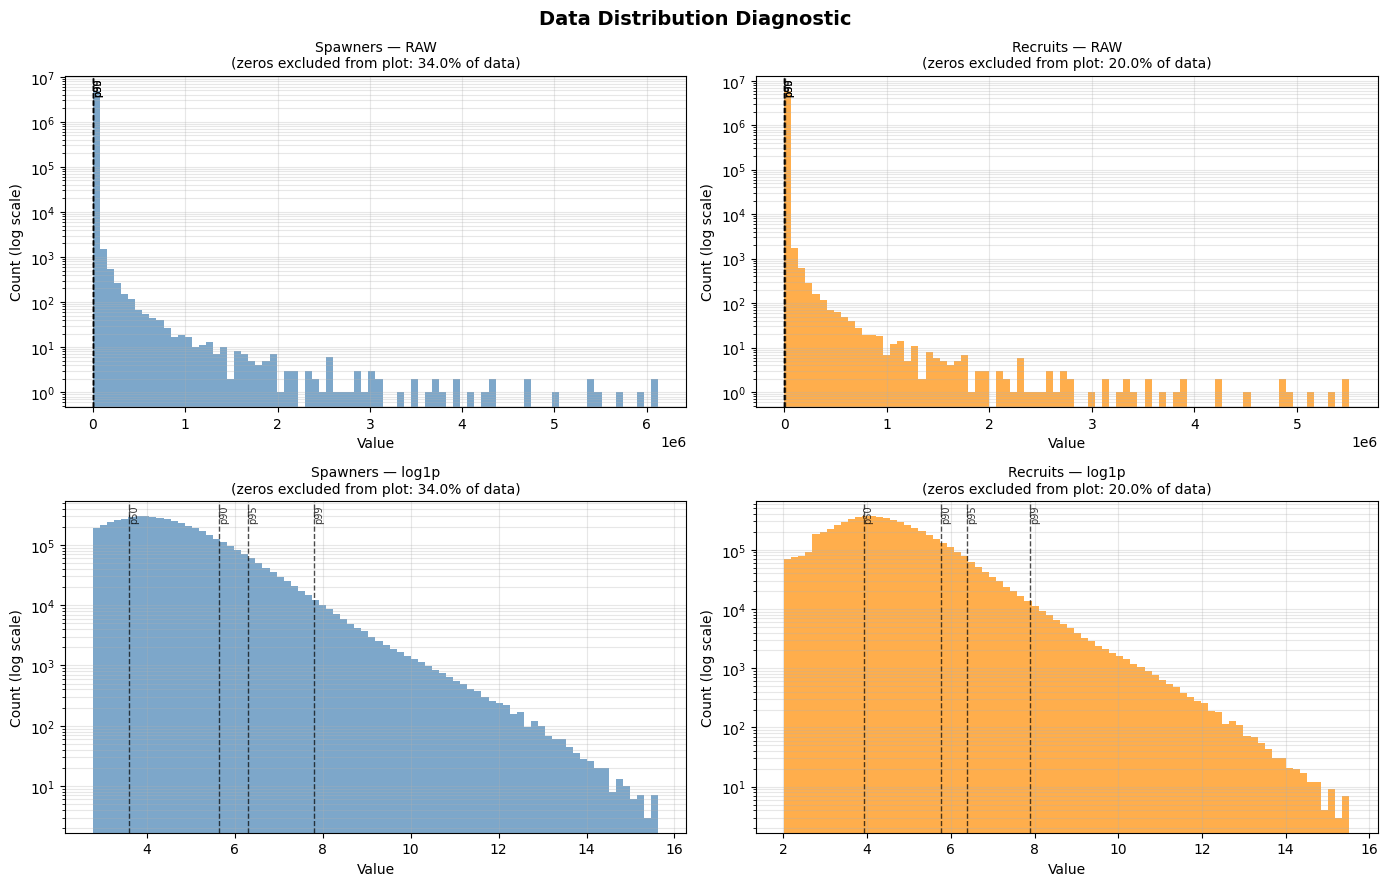

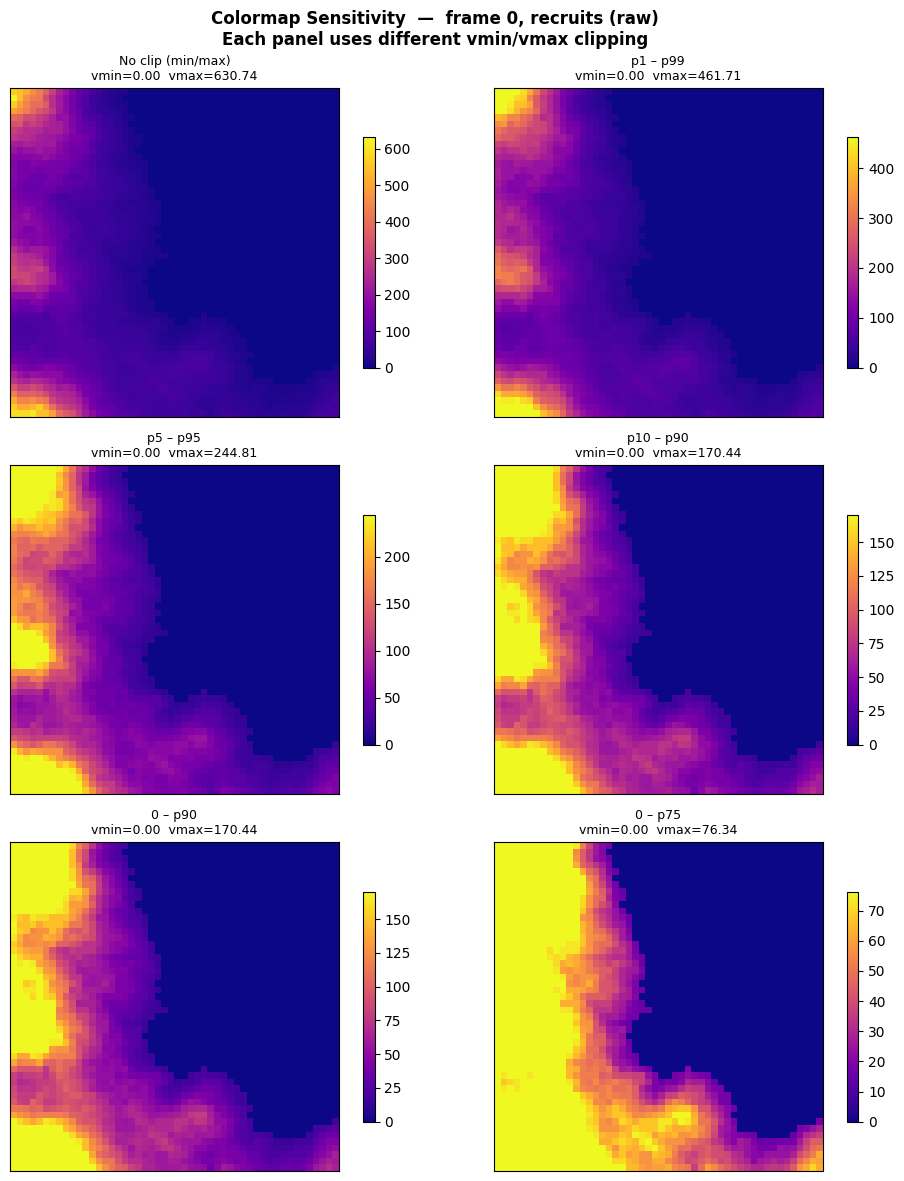


✓  Both diagnostic plots saved to your Drive.

Once you see these, the fix is usually one of:
  • Your data is heavily zero-inflated → use vmin=0, vmax=p90 or p95
  • A few extreme outliers stretch the scale → clip to p1–p99
  • log1p helps but the non-zero values are still right-skewed → try sqrt


In [ ]:
"""
data_distribution_diagnostic.py
---------------------------------
Run this in Colab to understand your data distribution before deciding
how to fix the color scales in the spatial plots.
"""

import numpy as np
import matplotlib.pyplot as plt
import os

REPO_DIR    = "/content/Teleconnections-ViT"
RAW_DATA    = os.path.join(REPO_DIR, "data/dummy/output")
DRIVE_DIR   = "/content/drive/MyDrive/Teleconnection_ViT"

# Load raw arrays
spawners = np.load(os.path.join(RAW_DATA, "gmrf_spawners_50x50.npy"))
recruits = np.load(os.path.join(RAW_DATA, "gmrf_recruits_50x50.npy"))

sp = spawners.ravel()
rc = recruits.ravel()
sp_log = np.log1p(sp)   # log(1+x)
rc_log = np.log1p(rc)

# ---------------------------------------------------------------------------
# PRINT SUMMARY TABLE
# ---------------------------------------------------------------------------

def summarize(arr, name):
    pcts = [0, 1, 5, 25, 50, 75, 90, 95, 99, 99.9, 100]
    vals = np.percentile(arr, pcts)
    zero_frac = np.mean(arr == 0) * 100
    near_zero_frac = np.mean(arr < 1e-6) * 100

    print(f"\n{'='*55}")
    print(f"  {name}   (n = {len(arr):,})")
    print(f"{'='*55}")
    print(f"  min       = {arr.min():.4f}")
    print(f"  max       = {arr.max():.4f}")
    print(f"  mean      = {arr.mean():.4f}")
    print(f"  std       = {arr.std():.4f}")
    print(f"  % zeros          = {zero_frac:.1f}%")
    print(f"  % near-zero(<1e-6) = {near_zero_frac:.1f}%")
    print(f"\n  Percentiles:")
    for p, v in zip(pcts, vals):
        bar = "█" * int(v / arr.max() * 30) if arr.max() > 0 else ""
        print(f"    p{p:>5.1f} = {v:>12.4f}  {bar}")

summarize(sp,     "SPAWNERS  (raw)")
summarize(rc,     "RECRUITS  (raw)")
summarize(sp_log, "SPAWNERS  (log1p)")
summarize(rc_log, "RECRUITS  (log1p)")

# ---------------------------------------------------------------------------
# PLOT: histograms + percentile markers
# ---------------------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Data Distribution Diagnostic", fontsize=14, fontweight="bold")

# Key percentiles to mark
mark_pcts = [50, 90, 95, 99]

def plot_hist(ax, arr, title, color, log_yscale=True):
    # Use log y-scale to see the tail
    arr_nonzero = arr[arr > 1e-6]
    zero_pct = np.mean(arr == 0) * 100

    ax.hist(arr_nonzero, bins=80, color=color, alpha=0.7, edgecolor="none")

    # Mark percentiles
    for p in mark_pcts:
        v = np.percentile(arr, p)
        ax.axvline(v, color="black", lw=1.0, linestyle="--", alpha=0.7)
        ax.text(v, ax.get_ylim()[1] * 0.8, f"p{p}", fontsize=7,
                ha="left", rotation=90, alpha=0.8)

    if log_yscale:
        ax.set_yscale("log")

    ax.set_title(f"{title}\n(zeros excluded from plot: {zero_pct:.1f}% of data)", fontsize=10)
    ax.set_xlabel("Value")
    ax.set_ylabel("Count (log scale)")
    ax.grid(True, alpha=0.3, which="both")

plot_hist(axes[0, 0], sp,     "Spawners — RAW",    "steelblue")
plot_hist(axes[0, 1], rc,     "Recruits — RAW",    "darkorange")
plot_hist(axes[1, 0], sp_log, "Spawners — log1p",  "steelblue")
plot_hist(axes[1, 1], rc_log, "Recruits — log1p",  "darkorange")

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_DIR, "data_distribution.png"), dpi=120)
plt.show()

# ---------------------------------------------------------------------------
# PLOT: what different vmin/vmax choices look like on a single example frame
# ---------------------------------------------------------------------------

fig2, axes2 = plt.subplots(3, 2, figsize=(10, 12))
fig2.suptitle(
    "Colormap Sensitivity  —  frame 0, recruits (raw)\n"
    "Each panel uses different vmin/vmax clipping",
    fontsize=12, fontweight="bold",
)

example_frame = recruits[0]   # first frame

clip_choices = [
    ("No clip (min/max)",  example_frame.min(),         example_frame.max()),
    ("p1 – p99",           np.percentile(example_frame, 1),  np.percentile(example_frame, 99)),
    ("p5 – p95",           np.percentile(example_frame, 5),  np.percentile(example_frame, 95)),
    ("p10 – p90",          np.percentile(example_frame, 10), np.percentile(example_frame, 90)),
    ("0 – p90",            0,                               np.percentile(example_frame, 90)),
    ("0 – p75",            0,                               np.percentile(example_frame, 75)),
]

for ax, (label, vmin, vmax) in zip(axes2.ravel(), clip_choices):
    im = ax.imshow(example_frame, cmap="plasma", vmin=vmin, vmax=vmax,
                   origin="lower", aspect="equal")
    fig2.colorbar(im, ax=ax, shrink=0.7)
    ax.set_title(f"{label}\nvmin={vmin:.2f}  vmax={vmax:.2f}", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_DIR, "colormap_sensitivity.png"), dpi=120)
plt.show()

print("\n✓  Both diagnostic plots saved to your Drive.")
print("\nOnce you see these, the fix is usually one of:")
print("  • Your data is heavily zero-inflated → use vmin=0, vmax=p90 or p95")
print("  • A few extreme outliers stretch the scale → clip to p1–p99")
print("  • log1p helps but the non-zero values are still right-skewed → try sqrt")

✓ Plot saved to /content/drive/MyDrive/Teleconnection_ViT/checkpoints/training_history.png


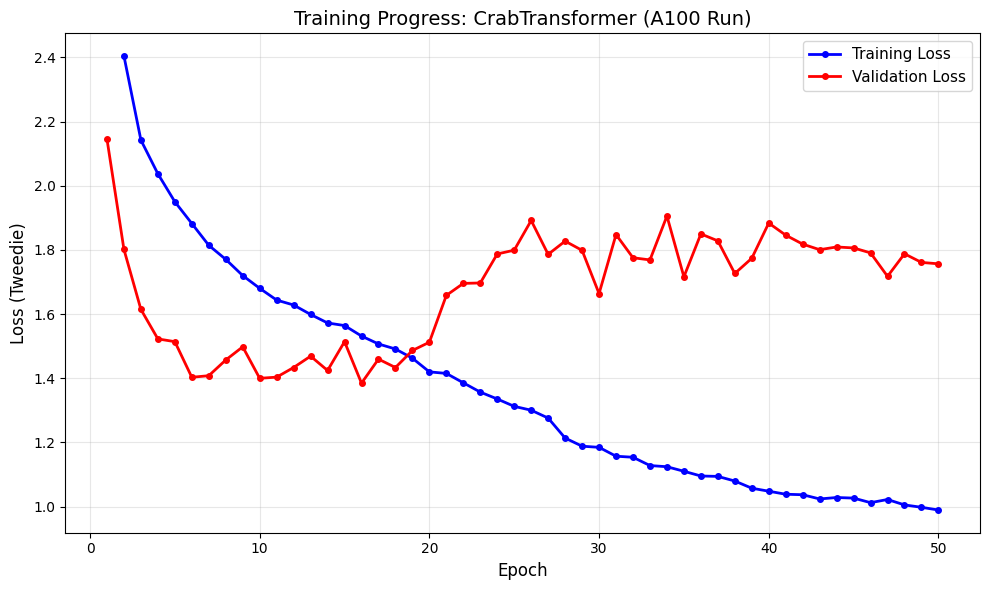

In [ ]:
import matplotlib.pyplot as plt
import glob
import re
import numpy as np

# 1. Use a regular expression to extract the number and sort numerically
def get_epoch_num(filename):
    match = re.search(r'epoch_(\d+)', filename)
    return int(match.group(1)) if match else 0

# Load and sort files correctly
checkpoint_files = glob.glob(os.path.join(DATA_PATH, "checkpoints/checkpoint_epoch_*.pt"))
checkpoint_files.sort(key=get_epoch_num) # Sorts 2 before 10

epochs = []
train_losses = []
val_losses = []

for cp_file in checkpoint_files:
    try:
        cp = torch.load(cp_file, map_location='cpu')
        epochs.append(cp['epoch'])
        train_losses.append(cp['train_loss'])
        val_losses.append(cp['val_loss'])
    except Exception as e:
        print(f"Skipping corrupted file {cp_file}: {e}")

# 2. Final safety check: Sort the lists together in case files were messy
# This ensures that even if filenames are weird, the x-axis (epochs) is strictly increasing
sorted_data = sorted(zip(epochs, train_losses, val_losses))
epochs, train_losses, val_losses = zip(*sorted_data)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(epochs[1:], train_losses[1:], 'b-o', label='Training Loss', linewidth=2, markersize=4)
plt.plot(epochs, val_losses, 'r-o', label='Validation Loss', linewidth=2, markersize=4)

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (Tweedie)', fontsize=12)
plt.title('Training Progress: CrabTransformer (A100 Run)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save and Show
save_path = os.path.join(DATA_PATH, 'checkpoints/training_history.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"✓ Plot saved to {save_path}")
plt.show()

Computed new Spawner Max: 889.5182
Computed new Recruit Max: 604.8356
Batch Correlation: 0.6957 (Should be > 0.7)


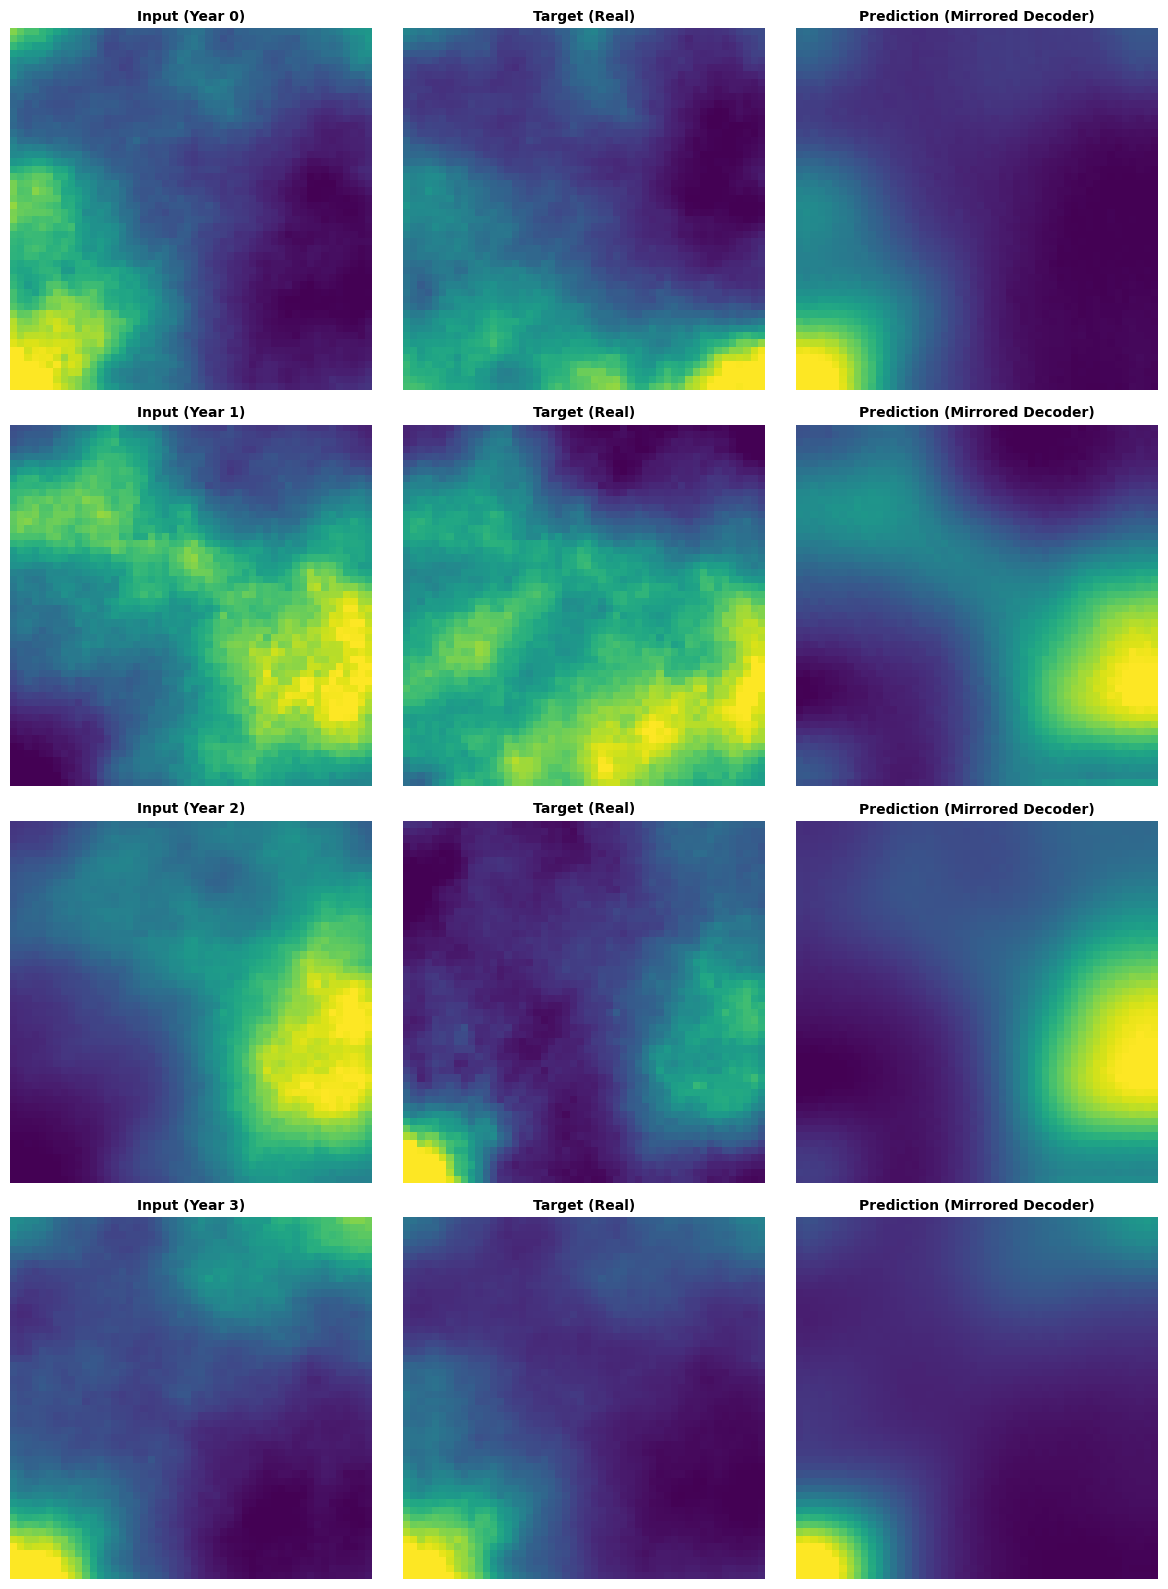

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Constants (from your new run logs)
train_ds = CrabDataset(
        os.path.join(DATA_PATH, "train_spawners.npy"),
        os.path.join(DATA_PATH, "train_recruits.npy"),
        n_years=22, spawner_max=None, recruit_max=None
    )

SPAWN_MAX = train_ds.spawner_max
RECRUIT_MAX = train_ds.recruit_max

# 2. Get a batch
model.eval()
with torch.no_grad():
    inputs, targets, year_indices = next(iter(val_loader))
    inputs, targets, year_indices = inputs.to(device), targets.to(device), year_indices.to(device)
    predictions = model(inputs, year_indices)

# 3. Denormalize
inputs_np = inputs.cpu().numpy() * SPAWN_MAX
targets_np = targets.cpu().numpy() * RECRUIT_MAX
preds_np = predictions.cpu().numpy() * RECRUIT_MAX

# 4. Calculate Correlation for this batch (Sanity Check)
batch_corr = np.corrcoef(preds_np.flatten(), targets_np.flatten())[0, 1]
print(f"Batch Correlation: {batch_corr:.4f} (Should be > 0.7)")

# 5. Plot
fig, axes = plt.subplots(4, 3, figsize=(12, 16))

# Helper to remove ticks
def clean_plot(ax, data, title):
    # Use robust scaling (1st-99th percentile) to ignore any remaining outliers
    vmin, vmax = np.percentile(data, [1, 99])
    im = ax.imshow(data, cmap='viridis', vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.axis('off')
    return im

for i in range(4):
    clean_plot(axes[i, 0], inputs_np[i, 0], f"Input (Year {year_indices[i].item()})")
    clean_plot(axes[i, 1], targets_np[i, 0], "Target (Real)")
    clean_plot(axes[i, 2], preds_np[i, 0], "Prediction (Mirrored Decoder)")

plt.tight_layout()
plt.show()

📊 Calculating Global Metrics...

✅ Global Correlation: 0.7796


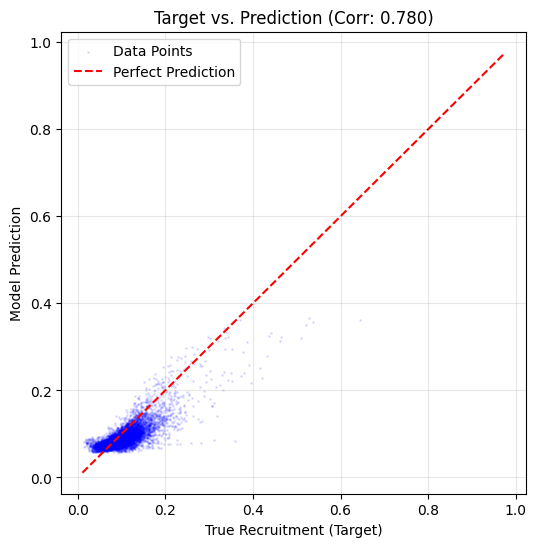

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

print("📊 Calculating Global Metrics...")

all_preds = []
all_targets = []

model.eval()
with torch.no_grad():
    for inputs, targets, year_indices in val_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        # Get predictions
        outputs = model(inputs, year_indices)

        # Collect data (flattened)
        all_preds.append(outputs.cpu().numpy().flatten())
        all_targets.append(targets.cpu().numpy().flatten())

# Concatenate all batches
global_preds = np.concatenate(all_preds)
global_targets = np.concatenate(all_targets)

# 1. Calculate Global Correlation
global_corr = np.corrcoef(global_preds, global_targets)[0, 1]

print(f"\n✅ Global Correlation: {global_corr:.4f}")

# 2. Scatter Plot (The Truth Detector)
# We plot a random subset of points to keep it fast
sample_indices = np.random.choice(len(global_preds), size=10000, replace=False)

plt.figure(figsize=(6, 6))
plt.scatter(global_targets[sample_indices], global_preds[sample_indices],
            alpha=0.1, s=1, c='blue', label='Data Points')

# Add 1:1 Line (Perfect Prediction)
min_val = min(global_targets.min(), global_preds.min())
max_val = max(global_targets.max(), global_preds.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction')

plt.title(f"Target vs. Prediction (Corr: {global_corr:.3f})")
plt.xlabel("True Recruitment (Target)")
plt.ylabel("Model Prediction")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib.patches import Rectangle
from google.colab import drive

# --- 1. MOUNT DRIVE (If not already mounted) ---
if not os.path.exists('/content/drive'):
    print("Mounting Google Drive...")
    drive.mount('/content/drive')

# --- 2. CONFIGURATION ---
BOOTSTRAP_IDX = 0
GRID_SIZE = 50

# PATH 1: The Local GitHub Repo (Contains the 50x50 dummy data)
REPO_DIR = '/content/Teleconnections-ViT'

# PATH 2: Google Drive (Contains Splits and Checkpoints)
# ⚠️ UPDATE THIS LINE to match your Drive folder structure!
# It likely looks like: "/content/drive/MyDrive/Teleconnections-ViT"
DRIVE_DIR = "/content/drive/MyDrive/Teleconnection_ViT"

# Construct absolute paths
DUMMY_DATA_DIR = os.path.join(REPO_DIR, "data/dummy/output")      # From GitHub
SPLIT_DIR = DRIVE_DIR        # From Drive
CHECKPOINT_PATH = os.path.join(DRIVE_DIR, "checkpoints/best_model_maxscaled.pt") # From Drive
SAVE_DIR = os.path.join(DRIVE_DIR, "analysis/full_bootstrap_viz") # Save back to Drive

# Split boundaries
TRAIN_END = 22
VAL_END = 27
TEST_END = 30

def visualize_full_trajectory():
    os.makedirs(SAVE_DIR, exist_ok=True)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # --- DIAGNOSTIC CHECKS ---
    print("\n--- Checking Paths ---")
    if not os.path.exists(DUMMY_DATA_DIR):
        print(f"❌ ERROR: Dummy data not found at: {DUMMY_DATA_DIR}")
        print("   Did the git clone finish successfully?")
        return
    if not os.path.exists(SPLIT_DIR):
        print(f"❌ ERROR: Splits not found at: {SPLIT_DIR}")
        print("   Check your DRIVE_DIR path.")
        return
    if not os.path.exists(CHECKPOINT_PATH):
        print(f"❌ ERROR: Checkpoint not found at: {CHECKPOINT_PATH}")
        print("   Check your DRIVE_DIR path.")
        return
    print("✅ All paths verified.\n")

    # 1. Load Normalization Constants (From Drive Splits)
    print("Loading training stats for normalization...")
    train_spawners = np.load(os.path.join(SPLIT_DIR, "train_spawners.npy"))
    train_recruits = np.load(os.path.join(SPLIT_DIR, "train_recruits.npy"))

    SPAWN_MAX = np.max(train_spawners) + 1e-6
    RECRUIT_MAX = np.max(train_recruits) + 1e-6
    print(f"Normalization Max | Spawners: {SPAWN_MAX:.2f} | Recruits: {RECRUIT_MAX:.2f}")

    # 2. Load the Model
    print(f"Loading model...")
    # Make sure we are in the repo dir so Python can find 'model.py' or 'components.py'
    # if your CrabTransformer class is defined in a file there.
    if REPO_DIR not in sys.path:
        sys.path.append(REPO_DIR)

    model = CrabTransformer(
        grid_size=50, patch_size=5, in_channels=1,
        embed_dim=128, num_heads=8, num_layers=6, d_ff=512, dropout=0.0
    ).to(device)

    # Load weights from Drive
    model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
    model.eval()

    # 3. Load the Full Bootstrap Data (From Local GitHub)
    print(f"Loading Bootstrap {BOOTSTRAP_IDX} from full dataset...")
    all_spawners = np.load(os.path.join(DUMMY_DATA_DIR, "gmrf_spawners_50x50.npy"))
    all_recruits = np.load(os.path.join(DUMMY_DATA_DIR, "gmrf_recruits_50x50.npy"))

    start_idx = BOOTSTRAP_IDX * 30
    end_idx = start_idx + 30

    b_spawners = all_spawners[start_idx:end_idx]
    b_recruits = all_recruits[start_idx:end_idx]

    # 4. Run Predictions Loop
    print("Running predictions...")
    preds_denorm = []

    with torch.no_grad():
        for t in range(30):
            # Prepare Input
            raw_sp = b_spawners[t]
            norm_sp = raw_sp / SPAWN_MAX

            input_tensor = torch.tensor(norm_sp, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
            year_tensor = torch.tensor([t], dtype=torch.long).to(device)

            output = model(input_tensor, year_tensor)

            pred_val = output.cpu().numpy().squeeze() * RECRUIT_MAX
            preds_denorm.append(pred_val)

    preds_denorm = np.array(preds_denorm)

    # 5. GENERATE PLOTS
    print("Generating visualization...")

    # --- PLOT A: Time Series ---
    center_y, center_x = GRID_SIZE // 2, GRID_SIZE // 2
    ts_target = b_recruits[:, center_y, center_x]
    ts_pred = preds_denorm[:, center_y, center_x]

    plt.figure(figsize=(12, 6))
    plt.axvspan(0, TRAIN_END-1, color='green', alpha=0.1, label='Training')
    plt.axvspan(TRAIN_END-1, VAL_END-1, color='orange', alpha=0.1, label='Validation')
    plt.axvspan(VAL_END-1, TEST_END-1, color='red', alpha=0.1, label='Test')

    plt.plot(ts_target, 'k-o', linewidth=2, label='True Recruitment')
    plt.plot(ts_pred, 'b--', linewidth=2, label='Model Prediction')

    plt.title(f"30-Year Trajectory (Bootstrap {BOOTSTRAP_IDX}) - Center Pixel", fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(SAVE_DIR, "bootstrap_timeseries.png"))
    plt.close()

    # --- PLOT B: Spatial Grid ---
    fig, axes = plt.subplots(30, 3, figsize=(10, 60))
    vmin_r, vmax_r = np.percentile(b_recruits, [1, 99])

    for t in range(30):
        if t < TRAIN_END: phase = "TRAIN"
        elif t < VAL_END: phase = "VAL"
        else: phase = "TEST"

        axes[t, 0].imshow(b_spawners[t], cmap='viridis')
        axes[t, 0].set_ylabel(f"Year {t}\n({phase})", fontsize=12, fontweight='bold')
        axes[t, 0].set_xticks([]); axes[t, 0].set_yticks([])

        axes[t, 1].imshow(b_recruits[t], cmap='plasma', vmin=vmin_r, vmax=vmax_r)
        axes[t, 1].axis('off')

        axes[t, 2].imshow(preds_denorm[t], cmap='plasma', vmin=vmin_r, vmax=vmax_r)
        axes[t, 2].axis('off')

        color = 'green' if phase == 'TRAIN' else ('orange' if phase == 'VAL' else 'red')
        rect = Rectangle((0,0), 49, 49, linewidth=3, edgecolor=color, facecolor='none')
        axes[t, 2].add_patch(rect)

    plt.tight_layout()
    save_path = os.path.join(SAVE_DIR, "bootstrap_spatial_frames.png")
    plt.savefig(save_path, dpi=100, bbox_inches='tight')
    plt.close()

    print(f"✓ Analysis complete!")
    print(f"  Files saved in: {SAVE_DIR}")

if __name__ == "__main__":
    visualize_full_trajectory()

Using device: cuda

--- Checking Paths ---
✅ All paths verified.

Loading training stats for normalization...
Normalization Max | Spawners: 889.52 | Recruits: 604.84
Loading model...
Sinusoidal temporal encoding initialized:
  Pre-computed years: 0-49
  Can dynamically compute beyond year 50 ✓
Initializing model weights...
✓ Weight initialization complete
Loading Bootstrap 0 from full dataset...
Running predictions...
Generating visualization...
✓ Analysis complete!
  Files saved in: /content/drive/MyDrive/Teleconnection_ViT/analysis/full_bootstrap_viz


Hooking into model to capture attention...


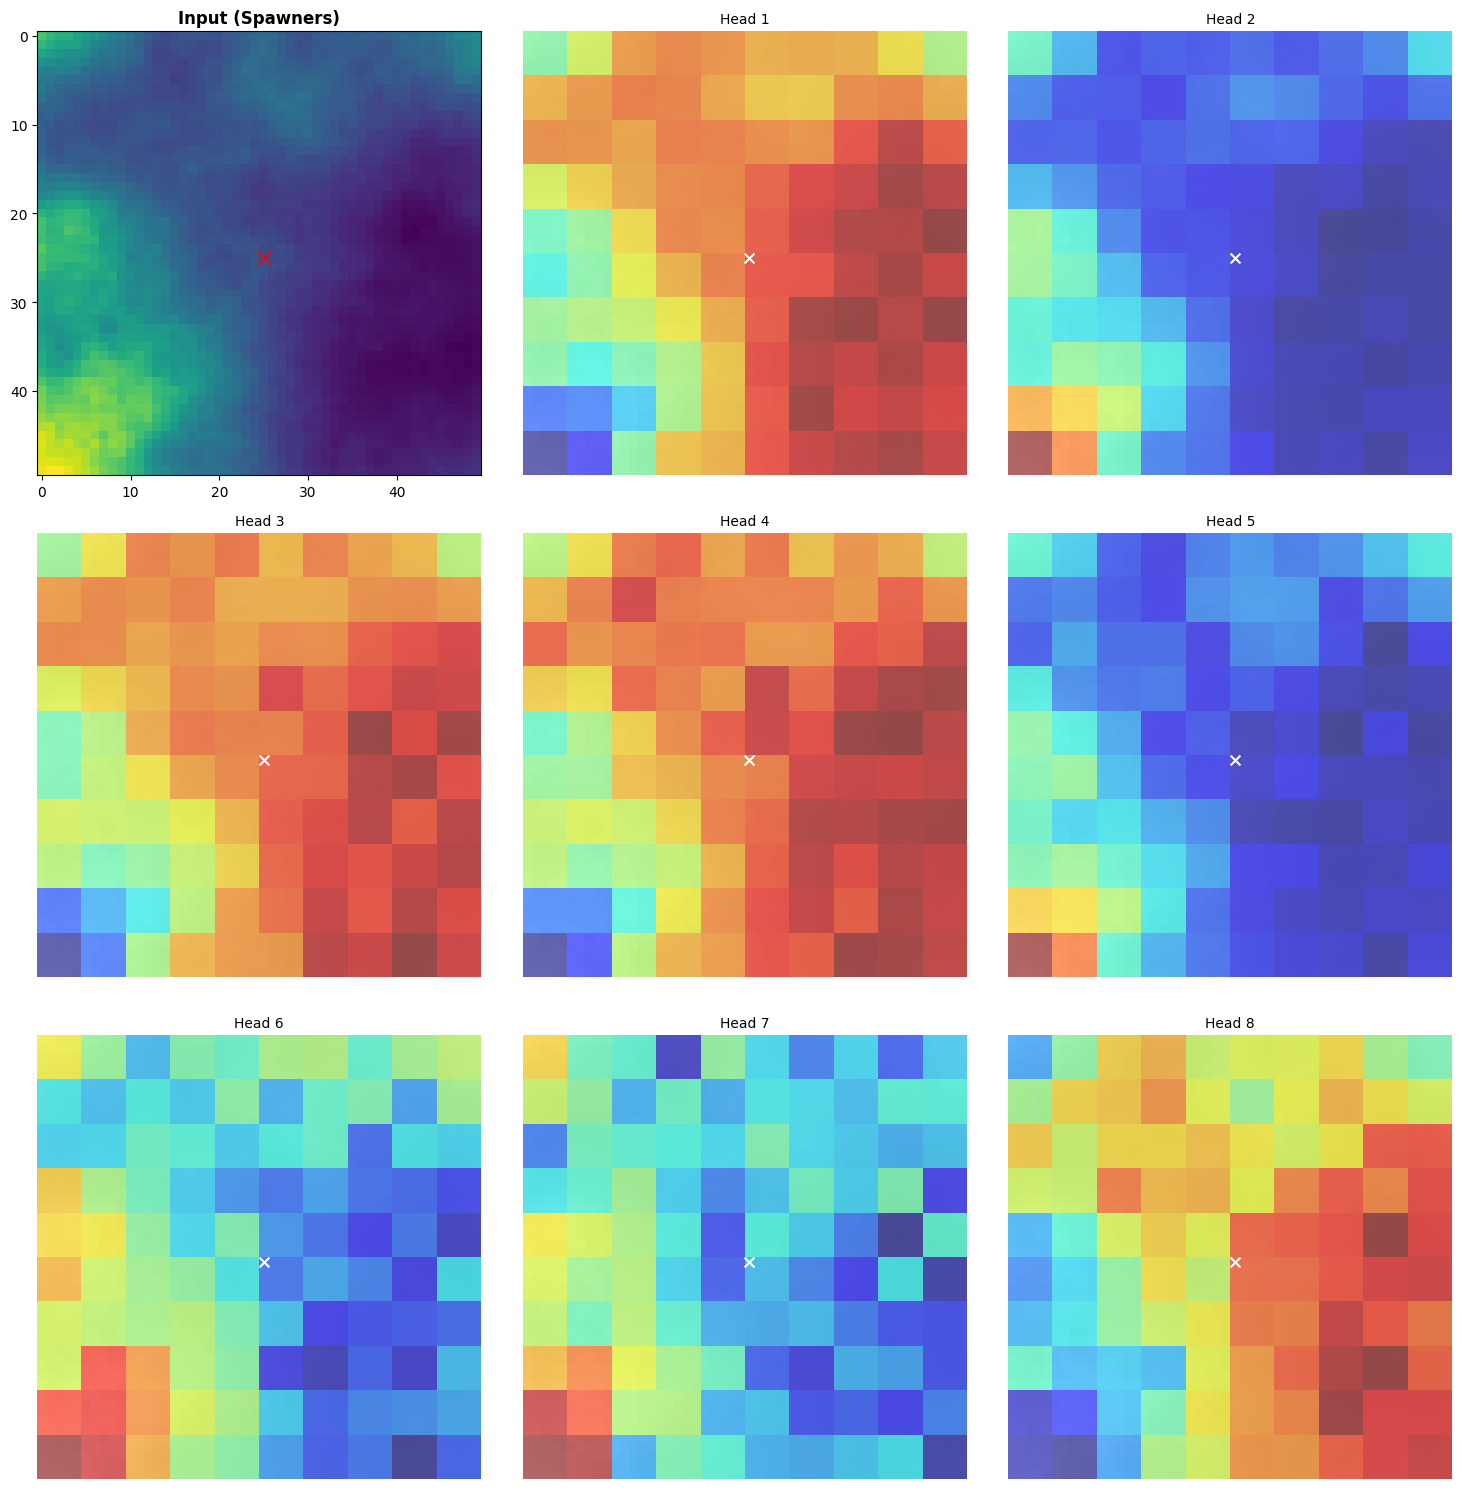

In [ ]:
def visualize_all_heads(model, val_loader, device):
    print("Hooking into model to capture attention...")

    # Storage for the weights
    captured_weights = []
    def hook_fn(module, input, output):
        captured_weights.append(input[0].detach().cpu())

    # 1. Register Hook (Same as before)
    block_list = [m for m in model.children() if isinstance(m, torch.nn.ModuleList)][0]
    target_layer = block_list[-1].attention.dropout
    hook_handle = target_layer.register_forward_hook(hook_fn)

    # 2. Run Batch
    model.eval()
    try:
        inputs, targets, year_idx = next(iter(val_loader))
        inputs = inputs.to(device)
        year_idx = year_idx.to(device)
        with torch.no_grad():
            _ = model(inputs, year_idx)
    finally:
        hook_handle.remove()

    # 3. Process Heads
    # attn_matrix shape: [Batch, 8, 100, 100]
    attn_matrix = captured_weights[0]
    batch_idx = 0
    center_patch_idx = 55 # Approx center of 10x10 grid

    # 4. PLOT GRID (1 Input + 8 Heads)
    fig, axes = plt.subplots(3, 3, figsize=(15, 15))
    axes = axes.flatten()

    # Plot 0: The Input
    input_img = inputs[batch_idx, 0].cpu().numpy()
    axes[0].imshow(input_img, cmap='viridis')
    axes[0].scatter([25], [25], c='red', marker='x', s=100)
    axes[0].set_title("Input (Spawners)", fontweight='bold')

    # Plot 1-8: The Attention Heads
    for head_idx in range(8):
        ax = axes[head_idx + 1]

        # Get this head's attention for the center patch
        head_attn = attn_matrix[batch_idx, head_idx, center_patch_idx, :] # [100]

        # Reshape to 10x10
        grid = head_attn.view(10, 10).numpy()

        # Normalize per head for visibility
        grid = (grid - grid.min()) / (grid.max() - grid.min() + 1e-8)

        # Resize to 50x50
        grid_resized = cv2.resize(grid, (50, 50), interpolation=cv2.INTER_NEAREST)

        # Overlay
        ax.imshow(input_img, cmap='gray', alpha=0.3)
        ax.imshow(grid_resized, cmap='jet', alpha=0.6)
        ax.scatter([25], [25], c='white', marker='x', s=50)
        ax.set_title(f"Head {head_idx+1}", fontsize=10)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# Run it
visualize_all_heads(model, val_loader, device)

In [ ]:
# 1. Recreate the Validation Loader (using constants from your logs)
print("--- Recreating Validation Loader ---")
# print the current directory:
print(os.getcwd())
SPAWN_MAX = train_ds.spawner_max
RECRUIT_MAX = train_ds.recruit_max

val_ds = CrabDataset(
    os.path.join(DATA_PATH, "val_spawners.npy"),
    os.path.join(DATA_PATH, "val_recruits.npy"),
    n_years=5,
    spawner_max=SPAWN_MAX,
    recruit_max=RECRUIT_MAX
)
val_loader = DataLoader(val_ds, batch_size=5, shuffle=False)

# 2. Load your saved model
print("--- Loading Saved Model ---")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CrabTransformer(
    grid_size=50, patch_size=5, in_channels=1,
    embed_dim=128, num_heads=8, num_layers=6, d_ff=512, dropout=0.1
).to(device)

# Load the best weights saved during your run
checkpoint_path = os.path.join(DATA_PATH, "checkpoints/best_model_maxscaled.pt")
model.load_state_dict(torch.load(checkpoint_path))
model.eval()

# 3. Run Correlation Analysis
print("\n📊 Running Correlation Analysis...")
all_preds = []
all_inputs = []
all_targets = []

with torch.no_grad():
    for inputs, targets, year_idx in val_loader:
        inputs, targets, year_idx = inputs.to(device), targets.to(device), year_idx.to(device)
        outputs = model(inputs, year_idx)

        all_preds.append(outputs.cpu().numpy())
        all_inputs.append(inputs.cpu().numpy())
        all_targets.append(targets.cpu().numpy())

# Flatten arrays
preds_np = np.concatenate(all_preds).flatten()
inputs_np = np.concatenate(all_inputs).flatten()
targets_np = np.concatenate(all_targets).flatten()

# Calculate
input_corr = np.corrcoef(preds_np, inputs_np)[0, 1]
print(f"Correlation (Input vs Prediction):  {input_corr:.4f}")

target_corr = np.corrcoef(preds_np, targets_np)[0, 1]
print(f"Correlation (Target vs Prediction): {target_corr:.4f}")

# Verdict
if input_corr > 0.9 and target_corr < 0.1:
    print("⚠️  WARNING: Model is stuck in Identity Trap.")
elif target_corr > 0.2:
    print("✅  SUCCESS: Model is learning recruitment patterns!")
else:
    print("ℹ️  Model is stable, but struggling to find strong signal.")

--- Recreating Validation Loader ---
/content/Teleconnections-ViT
Using provided Spawner Max: 889.5182
Using provided Recruit Max: 604.8356
--- Loading Saved Model ---
Sinusoidal temporal encoding initialized:
  Pre-computed years: 0-49
  Can dynamically compute beyond year 50 ✓
Initializing model weights...
✓ Weight initialization complete

📊 Running Correlation Analysis...
Correlation (Input vs Prediction):  0.9573
Correlation (Target vs Prediction): 0.7869
✅  SUCCESS: Model is learning recruitment patterns!


In [ ]:
import glob
import torch
import os

checkpoint_dir = os.path.join(DATA_PATH, "checkpoints")
checkpoints = glob.glob(os.path.join(checkpoint_dir, "*.pt"))

if checkpoints:
    print(f"Found {len(checkpoints)} checkpoint(s):\n")
    for cp in sorted(checkpoints):
        name = os.path.basename(cp)
        try:
            chkpt = torch.load(cp, map_location='cpu')
            print(f"  {name:30s} | Epoch {chkpt['epoch']:2d} | Train: {chkpt['train_loss']:.4f} | Val: {chkpt['val_loss']:.4f}")
        except:
            print(f"  {name:30s} | (Loading...)")
else:
    print("No checkpoints yet - training hasn't reached epoch 5")

Found 13 checkpoint(s):

  best_model.pt                  | Epoch 49 | Train: 0.7560 | Val: 0.7048
  best_model_maxscaled.pt        | (Loading...)
  checkpoint_epoch_10.pt         | Epoch 10 | Train: 0.8647 | Val: 0.7766
  checkpoint_epoch_15.pt         | (Loading...)
  checkpoint_epoch_20.pt         | Epoch 20 | Train: 0.7960 | Val: 0.7393
  checkpoint_epoch_25.pt         | Epoch 25 | Train: 0.7823 | Val: 0.7326
  checkpoint_epoch_30.pt         | Epoch 30 | Train: 0.7739 | Val: 0.7213
  checkpoint_epoch_35.pt         | Epoch 35 | Train: 0.7664 | Val: 0.7199
  checkpoint_epoch_40.pt         | Epoch 40 | Train: 0.7616 | Val: 0.7177
  checkpoint_epoch_45.pt         | Epoch 45 | Train: 0.7571 | Val: 0.7106
  checkpoint_epoch_5.pt          | Epoch  5 | Train: 1.0191 | Val: 0.8446
  checkpoint_epoch_50.pt         | Epoch 50 | Train: 0.7556 | Val: 0.7104
  final_model.pt                 | Epoch 50 | Train: 0.7556 | Val: 0.7104


In [ ]:
# Load best model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CrabTransformer(
    grid_size=50, patch_size=5, in_channels=1,
    embed_dim=128, num_heads=8, num_layers=6,
    d_ff=512, mask=None, dropout=0.1
).to(device)

checkpoint = torch.load(os.path.join(DATA_PATH, "checkpoints/best_model.pt"))
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"✓ Loaded best model from epoch {checkpoint['epoch']}")
print(f"  Validation Loss: {checkpoint['val_loss']:.4f}")

Sinusoidal temporal encoding initialized:
  Pre-computed years: 0-49
  Can dynamically compute beyond year 50 ✓
Initializing model weights...
✓ Weight initialization complete
✓ Loaded best model from epoch 49
  Validation Loss: 0.7048


In [ ]:
from torch.utils.data import DataLoader
from data.data_helper import CrabDataset
from models.losses import TweedieLoss

# Load test data
test_ds = CrabDataset(
    spawner_path=os.path.join(DATA_PATH, "test_spawners.npy"),
    recruit_path=os.path.join(DATA_PATH, "test_recruits.npy"),
    n_years=3,
    spawner_max=train_ds.spawner_max,
    recruit_max=train_ds.recruit_max
)
test_loader = DataLoader(test_ds, batch_size=5, shuffle=False)

# Evaluate
criterion = TweedieLoss(power=1.5)
#criterion = torch.nn.MSELoss()
total_test_loss = 0

with torch.no_grad():
    for inputs, targets, year_indices in test_loader:
        inputs, targets, year_indices = inputs.to(device), targets.to(device), year_indices.to(device)
        outputs = model(inputs, year_indices)
        loss = criterion(outputs, targets)
        total_test_loss += loss.item()

avg_test_loss = total_test_loss / len(test_loader)
print(f"Test Loss: {avg_test_loss:.4f}")

Computed new Spawner Max: 506.9257
Computed new Recruit Max: 465.9379
Test Loss: 1.4803


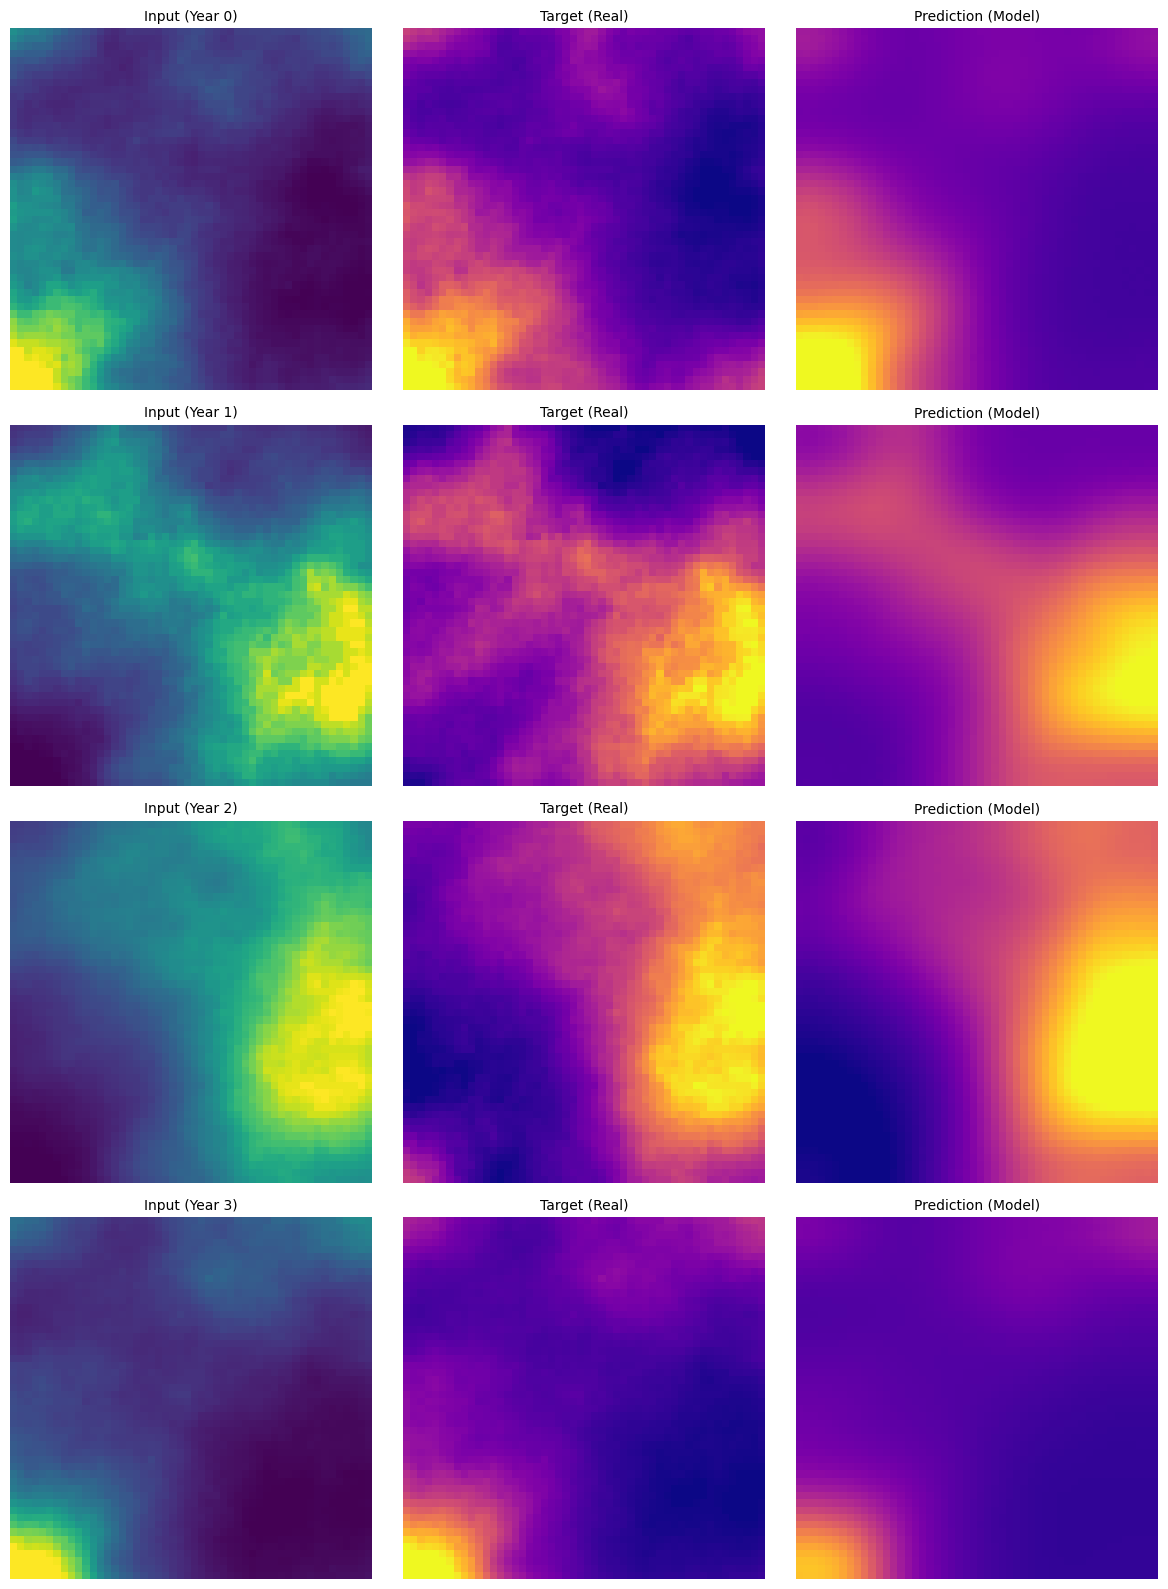

--- Debugging Values ---
Target Range:    9.69 to 364.10
Prediction Range:34.03 to 244.32


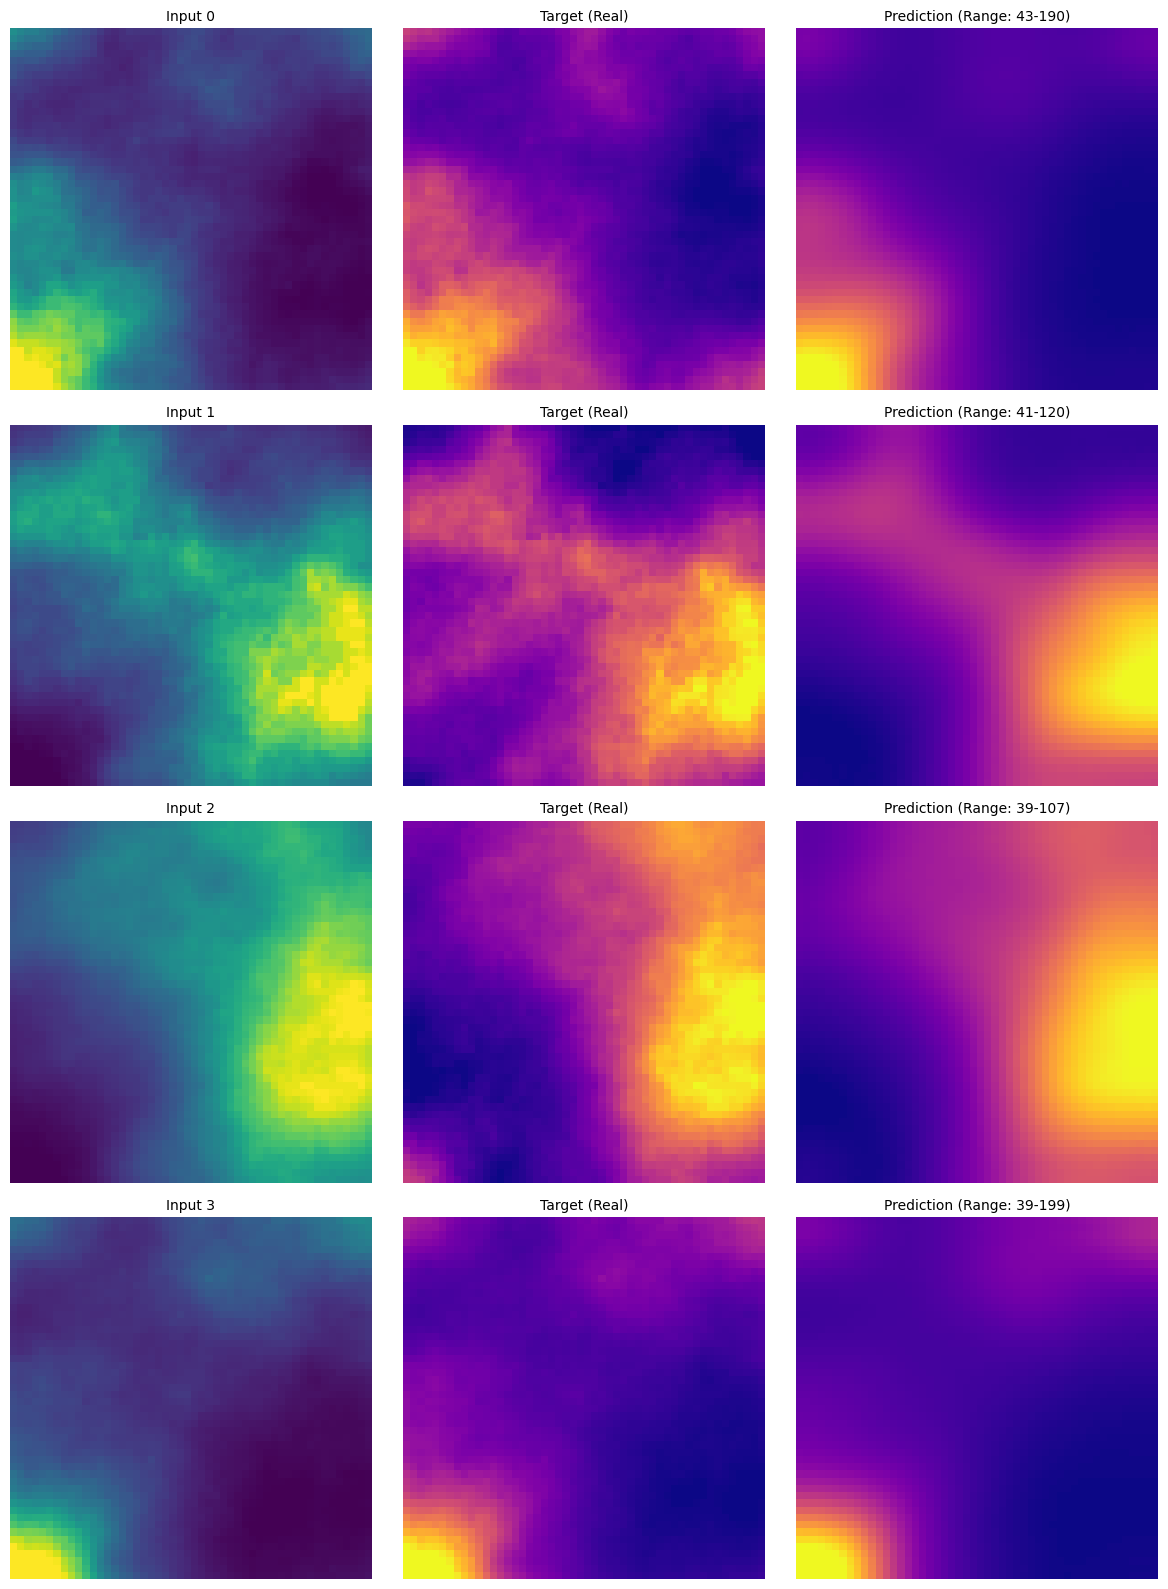

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Get a fresh batch
model.eval()
with torch.no_grad():
    inputs, targets, year_indices = next(iter(val_loader))
    inputs, targets, year_indices = inputs.to(device), targets.to(device), year_indices.to(device)
    predictions = model(inputs, year_indices)

# 2. Convert and Scale
inputs_np = inputs.cpu().numpy()
targets_np = targets.cpu().numpy()
preds_np = predictions.cpu().numpy()

# ⚠️ scaling by the constants you found
SPAWN_MAX = train_ds.spawner_max
RECRUIT_MAX = train_ds.recruit_max

inputs_real = inputs_np * SPAWN_MAX
targets_real = targets_np * RECRUIT_MAX
preds_real = preds_np * RECRUIT_MAX

# 3. ROBUST PLOTTING FUNCTION
def robust_plot(ax, data, title, cmap='viridis'):
    # Calculate the 99th percentile to ignore extreme outliers/borders
    vmin = np.percentile(data, 1)
    vmax = np.percentile(data, 99)

    im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=10)
    ax.axis('off')
    return im

fig, axes = plt.subplots(4, 3, figsize=(12, 16))

# Plot rows
for i in range(4):
    # Input
    robust_plot(axes[i, 0], inputs_real[i, 0], f"Input (Year {year_indices[i].item()})", cmap='viridis')

    # Target
    robust_plot(axes[i, 1], targets_real[i, 0], "Target (Real)", cmap='plasma')

    # Prediction
    # We use the Target's vmin/vmax for the Prediction to make them comparable
    target_min = np.percentile(targets_real[i, 0], 1)
    target_max = np.percentile(targets_real[i, 0], 99)

    im = axes[i, 2].imshow(preds_real[i, 0], cmap='plasma', vmin=target_min, vmax=target_max)
    axes[i, 2].set_title("Prediction (Model)", fontsize=10)
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

# 4. Debug Prints
print("--- Debugging Values ---")
print(f"Target Range:    {targets_real.min():.2f} to {targets_real.max():.2f}")
print(f"Prediction Range:{preds_real.min():.2f} to {preds_real.max():.2f}")


# Use the robust_plot function again, but this time...
# Let predictions determine their OWN vmin/vmax
fig, axes = plt.subplots(4, 3, figsize=(12, 16))

for i in range(4):
    # Input
    robust_plot(axes[i, 0], inputs_real[i, 0], f"Input {year_indices[i].item()}", cmap='viridis')

    # Target (Real)
    robust_plot(axes[i, 1], targets_real[i, 0], "Target (Real)", cmap='plasma')

    # Prediction (Model) - SCALED INDEPENDENTLY
    # We calculate percentiles from the PREDICTION data, not the target
    pred_data = preds_real[i, 0]
    p_min = np.percentile(pred_data, 1)
    p_max = np.percentile(pred_data, 99)

    im = axes[i, 2].imshow(pred_data, cmap='plasma', vmin=p_min, vmax=p_max)
    axes[i, 2].set_title(f"Prediction (Range: {p_min:.0f}-{p_max:.0f})", fontsize=10)
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

Using Constants -> Spawner Max: 529.08, Recruit Max: 524.01
Sinusoidal temporal encoding initialized:
  Pre-computed years: 0-49
  Can dynamically compute beyond year 50 ✓
Initializing model weights...
✓ Weight initialization complete
Computed new Spawner Max: 506.9257
Computed new Recruit Max: 465.9379


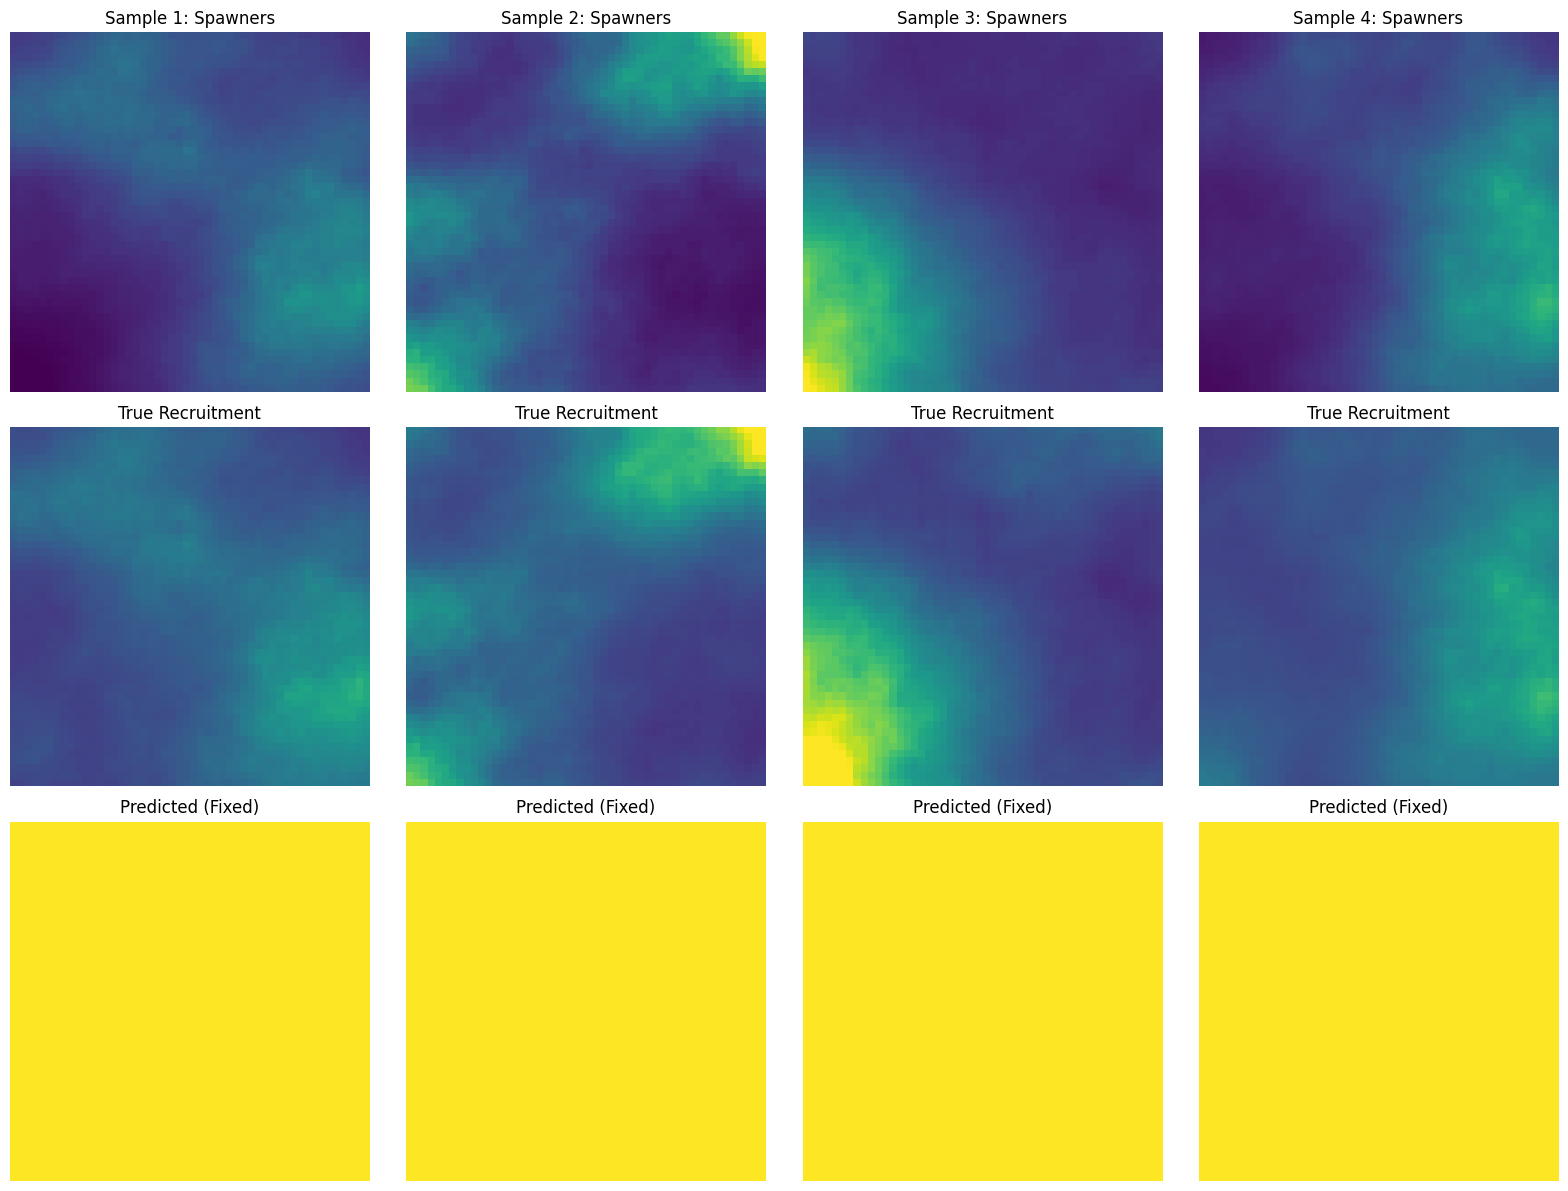

Prediction range: [226.19, 299.95]
Target range: [21.61, 268.02]


In [ ]:
# THIS ONE - Run after training completes
import numpy as np
import matplotlib.pyplot as plt


train_spawners = np.load(os.path.join(DATA_PATH, "train_spawners.npy"))
train_recruits = np.load(os.path.join(DATA_PATH, "train_recruits.npy"))
SPAWN_MAX = np.max(train_spawners) + 1e-6
RECRUIT_MAX = np.max(train_recruits) + 1e-6

print(f"Using Constants -> Spawner Max: {SPAWN_MAX:.2f}, Recruit Max: {RECRUIT_MAX:.2f}")


# Load model
checkpoint = torch.load(os.path.join(DATA_PATH, "checkpoints/best_model.pt"))
model = CrabTransformer(
    grid_size=50, patch_size=5, in_channels=1,
    embed_dim=128, num_heads=8, num_layers=6,
    d_ff=512, mask=None, dropout=0.1
).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# Get test data
test_ds = CrabDataset(
    os.path.join(DATA_PATH, "test_spawners.npy"),
    os.path.join(DATA_PATH, "test_recruits.npy"),
    n_years=3
)
test_loader = DataLoader(test_ds, batch_size=5, shuffle=False)

# Get predictions
with torch.no_grad():
    inputs, targets, year_indices = next(iter(test_loader))
    inputs, targets, year_indices = inputs.to(device), targets.to(device), year_indices.to(device)
    predictions = model(inputs, year_indices)

# Convert to numpy
inputs_np = inputs.cpu().numpy()
targets_np = targets.cpu().numpy()
preds_np = predictions.cpu().numpy()

# Denormalize
#SPAWN_MEAN, SPAWN_STD = 57.3167, 38.3864
#RECRUIT_MEAN, RECRUIT_STD = 49.9369, 24.3599

#inputs_denorm = inputs_np.copy()
#inputs_denorm[:, 0] = inputs_np[:, 0] * SPAWN_STD + SPAWN_MEAN
#inputs_denorm[:, 0] = inputs_np[:, 0] *
#inputs_denorm[:, 1] = inputs_np[:, 1] * RECRUIT_STD + RECRUIT_MEAN

#targets_denorm = targets_np * RECRUIT_STD + RECRUIT_MEAN
#preds_denorm = preds_np * RECRUIT_STD + RECRUIT_MEAN

inputs_denorm = inputs_np.copy()
inputs_denorm[:, 0] = inputs_np[:, 0] * SPAWN_MAX

targets_denorm = targets_np * RECRUIT_MAX
preds_denorm = preds_np * RECRUIT_MAX

# Plot
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for i in range(4):
    axes[0, i].imshow(inputs_denorm[i, 0], cmap='viridis', vmin=10, vmax=200)
    axes[0, i].set_title(f'Sample {i+1}: Spawners')
    axes[0, i].axis('off')

    axes[1, i].imshow(targets_denorm[i, 0], cmap='viridis', vmin=10, vmax=200)
    axes[1, i].set_title('True Recruitment')
    axes[1, i].axis('off')

    axes[2, i].imshow(preds_denorm[i, 0], cmap='viridis', vmin=10, vmax=200)
    axes[2, i].set_title('Predicted (Fixed)')
    axes[2, i].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'checkpoints/predictions_fixed.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print(f"Prediction range: [{preds_denorm.min():.2f}, {preds_denorm.max():.2f}]")
print(f"Target range: [{targets_denorm.min():.2f}, {targets_denorm.max():.2f}]")

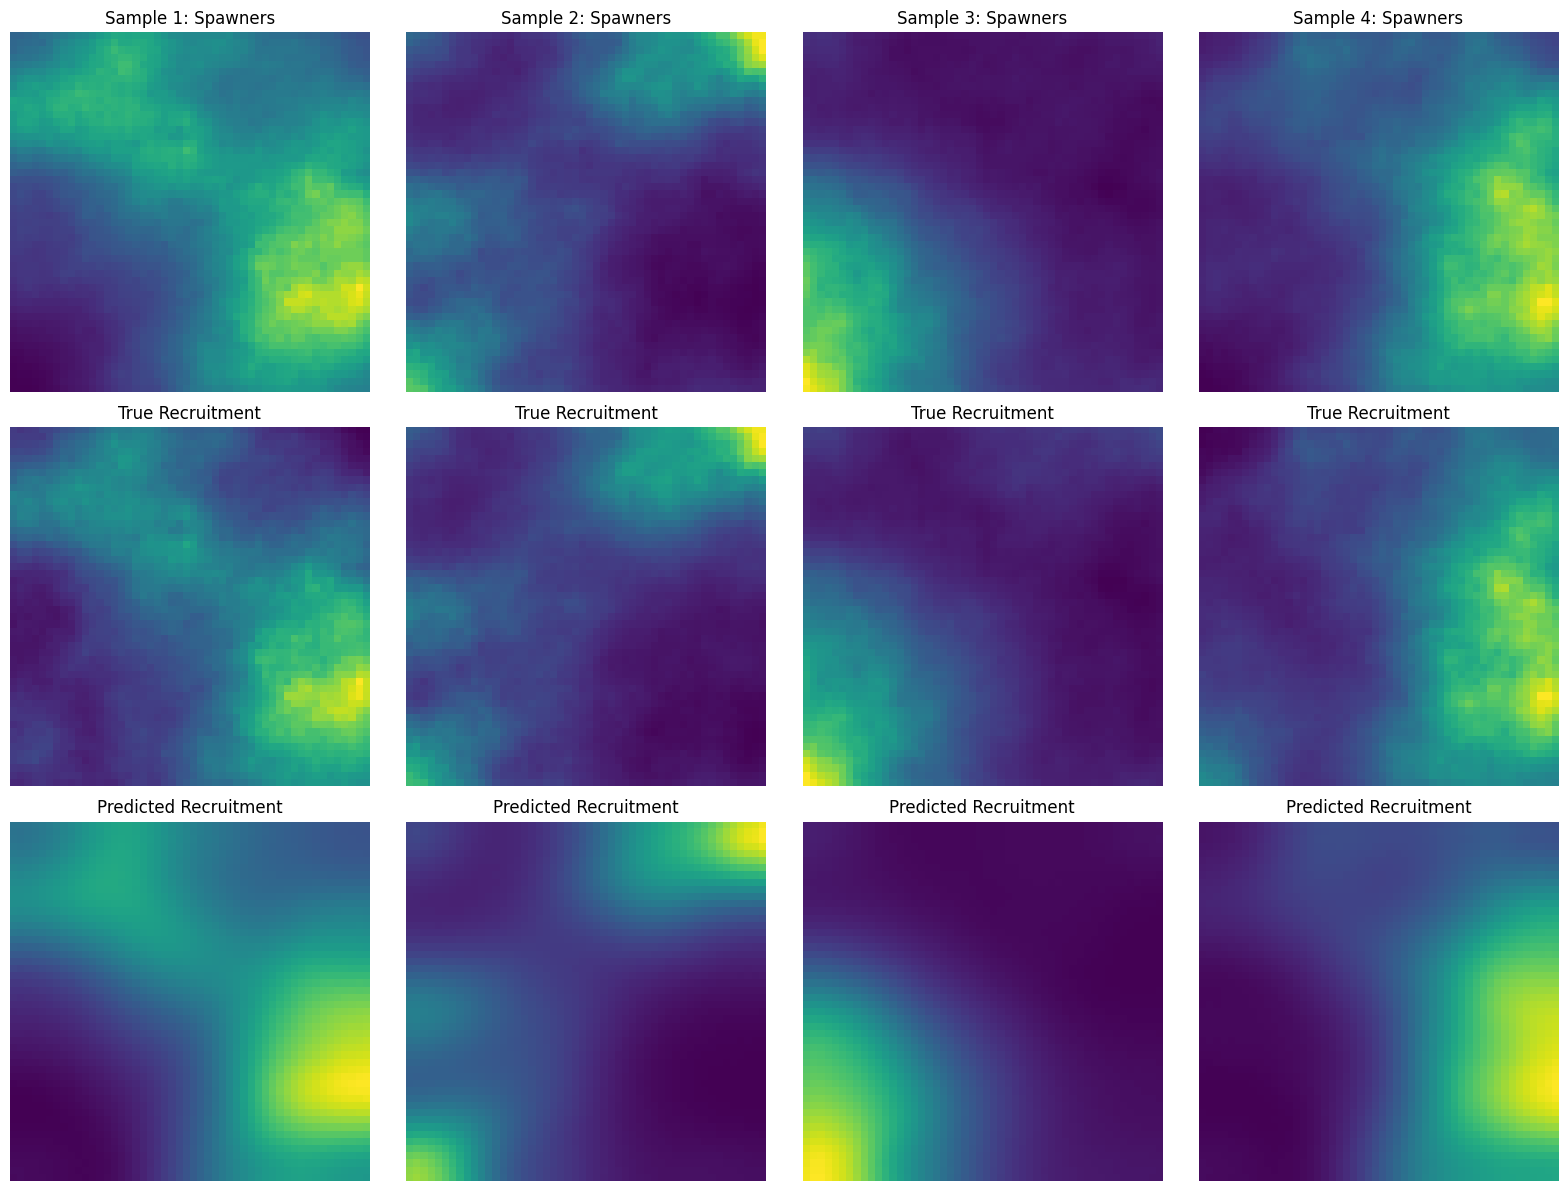

✓ Visualization saved!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Get a batch of predictions
model.eval()
with torch.no_grad():
    # Get first batch from test set
    inputs, targets, year_indices = next(iter(test_loader))
    inputs, targets, year_indices = inputs.to(device), targets.to(device), year_indices.to(device)
    predictions = model(inputs, year_indices)

# Move to CPU and convert to numpy
predictions = predictions.cpu().numpy()
targets = targets.cpu().numpy()
inputs = inputs.cpu().numpy()

# Plot a few examples
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for i in range(4):
    # Row 1: Spawner input (channel 0)
    axes[0, i].imshow(inputs[i, 0], cmap='viridis')
    axes[0, i].set_title(f'Sample {i+1}: Spawners')
    axes[0, i].axis('off')

    # Row 2: True recruitment
    axes[1, i].imshow(targets[i, 0], cmap='viridis')
    axes[1, i].set_title('True Recruitment')
    axes[1, i].axis('off')

    # Row 3: Predicted recruitment
    axes[2, i].imshow(predictions[i, 0], cmap='viridis')
    axes[2, i].set_title('Predicted Recruitment')
    axes[2, i].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'checkpoints/predictions_visualization.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✓ Visualization saved!")

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import torch

# =============================================================================
# FUNCTION 1: Basic Visualization
# =============================================================================

def show_predictions(model, dataloader, device, n_samples=3):
    """
    Show predictions vs ground truth side-by-side.

    Usage:
        show_predictions(model, val_loader, device='cuda', n_samples=3)
    """
    model.eval()

    # Get data
    inputs, targets, year_indices = next(iter(dataloader))
    inputs = inputs[:n_samples].to(device)
    targets = targets[:n_samples].to(device)
    year_indices = year_indices[:n_samples].to(device)

    # Get predictions
    with torch.no_grad():
        preds = model(inputs, year_indices)

    # Move to numpy
    inputs = inputs.cpu().numpy()
    targets = targets.cpu().numpy()
    preds = preds.cpu().numpy()

    # Plot
    fig, axes = plt.subplots(n_samples, 4, figsize=(16, 4*n_samples))

    for i in range(n_samples):
        # Input spawners
        ax = axes[i, 0] if n_samples > 1 else axes[0]
        im = ax.imshow(inputs[i, 0], cmap='viridis')
        ax.set_title('Input: Spawners')
        ax.axis('off')
        plt.colorbar(im, ax=ax)

        # Target
        ax = axes[i, 1] if n_samples > 1 else axes[1]
        im = ax.imshow(targets[i, 0], cmap='plasma')
        ax.set_title('Ground Truth')
        ax.axis('off')
        plt.colorbar(im, ax=ax)

        # Prediction
        ax = axes[i, 2] if n_samples > 1 else axes[2]
        im = ax.imshow(preds[i, 0], cmap='plasma')
        ax.set_title('Prediction')
        ax.axis('off')
        plt.colorbar(im, ax=ax)

        # Error
        ax = axes[i, 3] if n_samples > 1 else axes[3]
        error = preds[i, 0] - targets[i, 0]
        im = ax.imshow(error, cmap='RdBu_r',
                      vmin=-np.abs(error).max(),
                      vmax=np.abs(error).max())
        ax.set_title(f'Error (MAE={np.abs(error).mean():.2f})')
        ax.axis('off')
        plt.colorbar(im, ax=ax)

    plt.tight_layout()
    plt.show()

def check_artifacts(model, dataloader, device):
    """
    Check for ring/grid artifacts in decoder output.

    Usage:
        check_artifacts(model, val_loader, device='cuda')
    """
    model.eval()

    # Get one sample
    inputs, targets, year_indices = next(iter(dataloader))
    inputs = inputs[0:1].to(device)
    targets = targets[0:1].to(device)
    year_indices = year_indices[0:1].to(device)

    with torch.no_grad():
        pred = model(inputs, year_indices)

    pred = pred[0, 0].cpu().numpy()
    target = targets[0, 0].cpu().numpy()

    # Create figure
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    # 1. Prediction (full)
    ax = axes[0, 0]
    im = ax.imshow(pred, cmap='plasma')
    ax.set_title('Full Prediction\n(Look for rings/patterns)', fontsize=12, fontweight='bold')
    plt.colorbar(im, ax=ax)

    # 2. Ground truth (full)
    ax = axes[0, 1]
    im = ax.imshow(target, cmap='plasma')
    ax.set_title('Ground Truth\n(Should be smooth)', fontsize=12, fontweight='bold')
    plt.colorbar(im, ax=ax)

    # 3. Zoomed corner (prediction)
    ax = axes[0, 2]
    zoom = pred[:20, :20]
    im = ax.imshow(zoom, cmap='plasma', interpolation='none')
    ax.set_title('Zoomed Corner\n(Artifacts visible here)', fontsize=12, fontweight='bold')
    plt.colorbar(im, ax=ax)

    # Add patch grid at boundaries (every 5 pixels = patch size)
    for i in range(0, 20, 5):
        ax.axhline(i-0.5, color='white', linewidth=1, alpha=0.7)
        ax.axvline(i-0.5, color='white', linewidth=1, alpha=0.7)

    # 4. Horizontal slice through middle
    ax = axes[1, 0]
    middle = pred.shape[0] // 2
    ax.plot(pred[middle, :], 'b-', linewidth=2, label='Prediction')
    ax.plot(target[middle, :], 'r--', linewidth=2, alpha=0.7, label='Ground Truth')
    ax.set_title('Horizontal Slice (Middle Row)', fontsize=12)
    ax.set_xlabel('Column')
    ax.set_ylabel('Value')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Mark patch boundaries
    for i in range(0, 50, 5):
        ax.axvline(i, color='gray', linestyle=':', alpha=0.3)

    # 5. Vertical slice through middle
    ax = axes[1, 1]
    middle = pred.shape[1] // 2
    ax.plot(pred[:, middle], 'b-', linewidth=2, label='Prediction')
    ax.plot(target[:, middle], 'r--', linewidth=2, alpha=0.7, label='Ground Truth')
    ax.set_title('Vertical Slice (Middle Column)', fontsize=12)
    ax.set_xlabel('Row')
    ax.set_ylabel('Value')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Mark patch boundaries
    for i in range(0, 50, 5):
        ax.axvline(i, color='gray', linestyle=':', alpha=0.3)

    # 6. Gradient magnitude (shows edges)
    ax = axes[1, 2]
    grad_y = np.abs(np.diff(pred, axis=0, prepend=pred[0:1, :]))
    grad_x = np.abs(np.diff(pred, axis=1, prepend=pred[:, 0:1]))
    grad_mag = np.sqrt(grad_y**2 + grad_x**2)

    im = ax.imshow(grad_mag, cmap='hot')
    ax.set_title('Gradient Magnitude\n(Bright = sharp edges)', fontsize=12, fontweight='bold')
    plt.colorbar(im, ax=ax, label='Gradient')

    # Overlay patch grid
    for i in range(0, 50, 5):
        ax.axhline(i, color='cyan', linestyle=':', alpha=0.3, linewidth=0.5)
        ax.axvline(i, color='cyan', linestyle=':', alpha=0.3, linewidth=0.5)

    plt.tight_layout()
    plt.show()

    # Print diagnostics
    print("\n" + "="*60)
    print("ARTIFACT DIAGNOSTIC")
    print("="*60)

    # Check if gradients are high at patch boundaries
    boundary_grad = []
    interior_grad = []

    for i in range(pred.shape[0]):
        for j in range(pred.shape[1]):
            # Is this a patch boundary?
            if (i % 5 == 0 or j % 5 == 0) and i > 0 and j > 0 and i < 49 and j < 49:
                boundary_grad.append(grad_mag[i, j])
            elif i % 5 != 0 and j % 5 != 0:
                interior_grad.append(grad_mag[i, j])

    boundary_avg = np.mean(boundary_grad)
    interior_avg = np.mean(interior_grad)

    print(f"Average gradient at patch boundaries: {boundary_avg:.4f}")
    print(f"Average gradient in interior:         {interior_avg:.4f}")
    print(f"Ratio (boundary/interior):            {boundary_avg/interior_avg:.2f}x")

    if boundary_avg > interior_avg * 1.3:
        print("\n⚠️  WARNING: Patch boundaries are visible!")
        print("   Your decoder is creating grid artifacts.")
        print("   Recommendation: Use improved decoder (see below)")
    else:
        print("\n✓ Patch boundaries look smooth!")

    print("="*60)



Training on: cuda
Spawner norm: mean=56.8944, std=36.6632
Recruit norm: mean=49.6799, std=24.0246
Spawner norm: mean=57.3120, std=39.2794
Recruit norm: mean=49.6271, std=23.0386


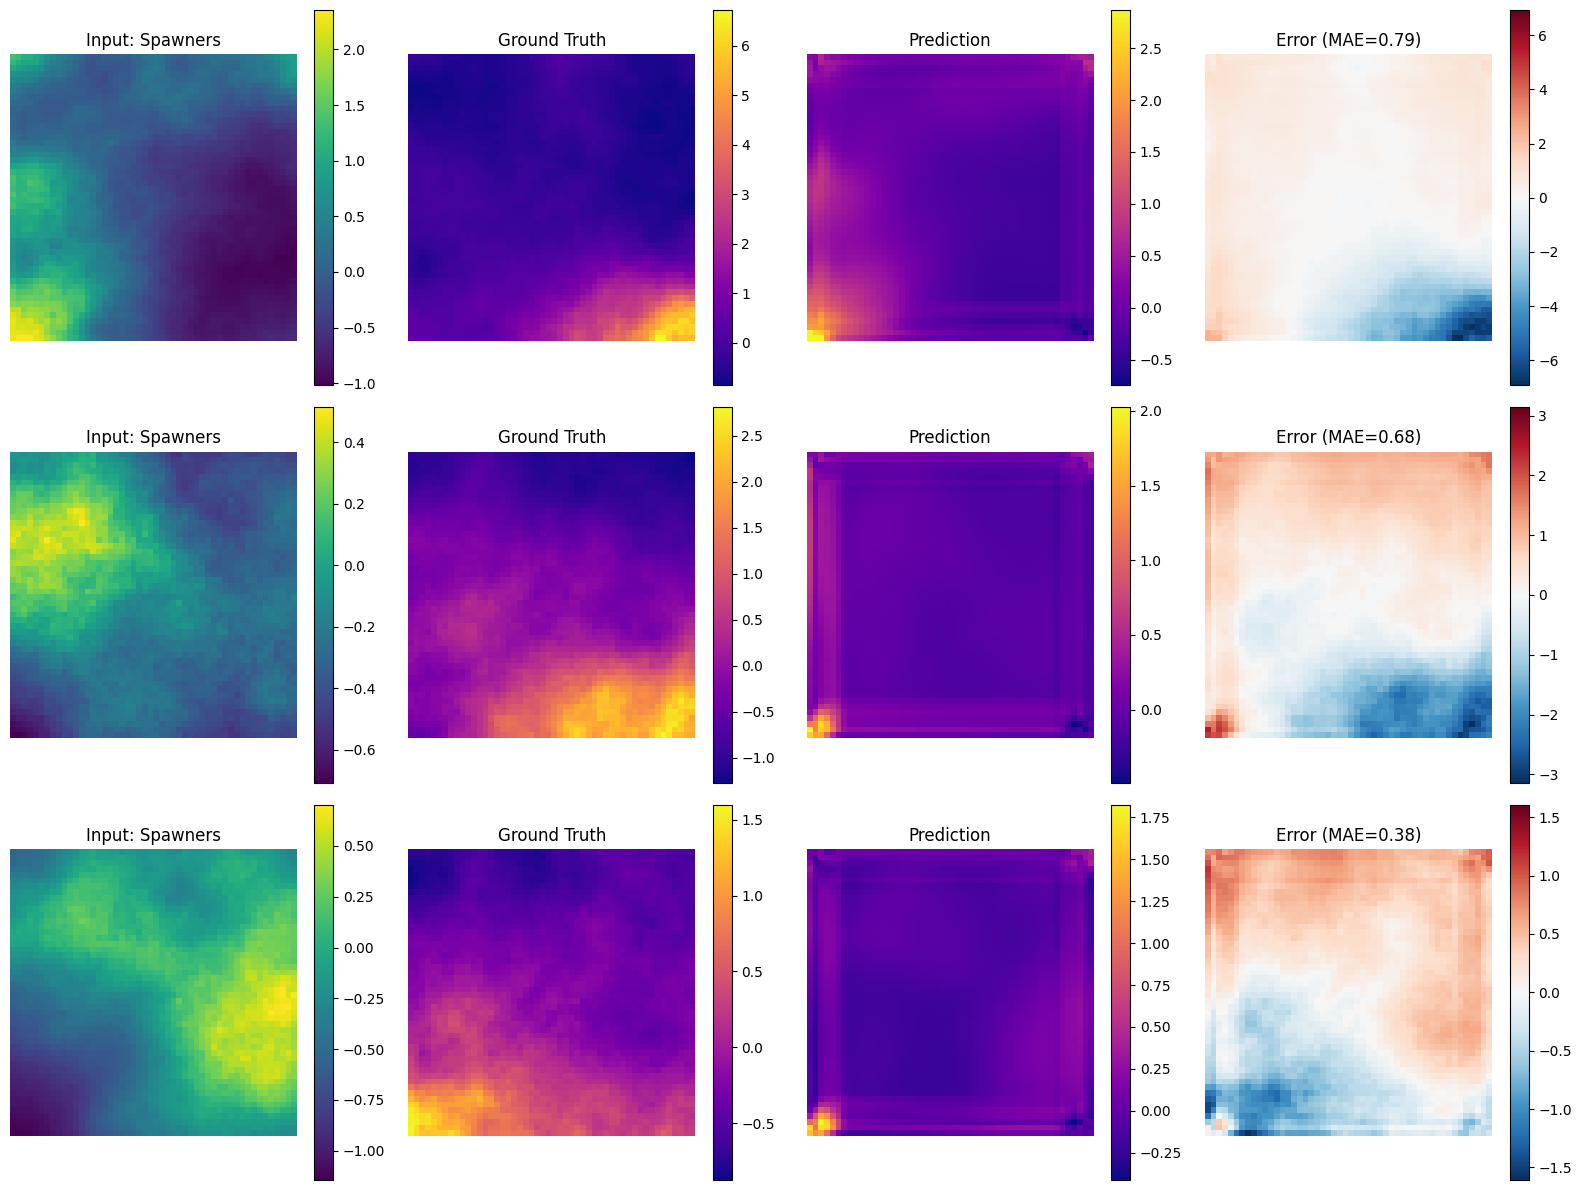

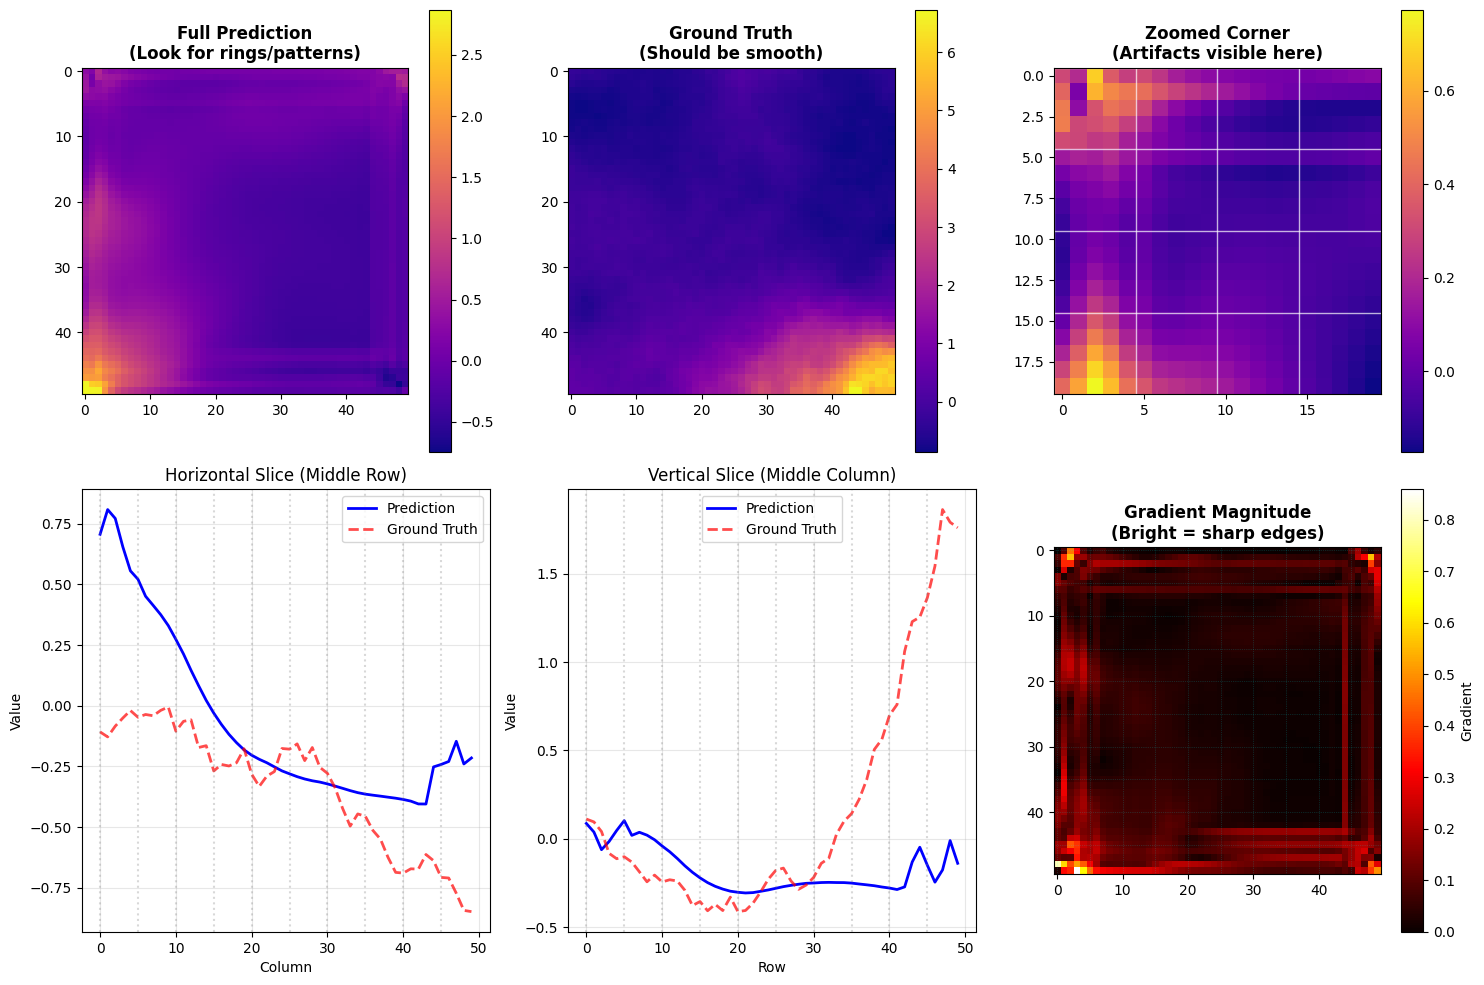


ARTIFACT DIAGNOSTIC
Average gradient at patch boundaries: 0.0527
Average gradient in interior:         0.0676
Ratio (boundary/interior):            0.78x

✓ Patch boundaries look smooth!


In [ ]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")
batch_size = 5
epochs = 50
learning_rate = 1e-4
grid_size = 50
patch_size = 5
in_channels = 1
embed_dim = 128
num_heads = 8
d_ff = 512
num_layers = 6
mask = None
dropout = 0.1

weight_decay = 1e-5
max_grad_norm = 1



    # prepare data
train_ds = CrabDataset(
        spawner_path=os.path.join(DATA_PATH, "train_spawners.npy"),
        recruit_path=os.path.join(DATA_PATH, "train_recruits.npy"),
        n_years=22
    )

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

val_ds = CrabDataset(
        spawner_path=os.path.join(DATA_PATH, "val_spawners.npy"),
        recruit_path=os.path.join(DATA_PATH, "val_recruits.npy"),
        n_years=5
    )

val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)


show_predictions(model, val_loader, 'cuda', n_samples=3)
check_artifacts(model, val_loader, 'cuda')

In [ ]:
## stop! is the data from github updated in the google drive?

def train_model():

    # set hyperparameters:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Training on: {device}")
    batch_size = 5
    epochs = 50
    learning_rate = 1e-4
    grid_size = 50
    patch_size = 5
    in_channels = 1
    embed_dim = 128
    num_heads = 8
    d_ff = 512
    num_layers = 6
    mask = None
    dropout = 0.1

    weight_decay = 1e-5
    max_grad_norm = 1

    patience = 15  # Number of epochs to wait for improvement
    min_delta = 1e-4  # Minimum change to qualify as improvement

    # Create checkpoint directory in Google Drive
    CHECKPOINT_DIR = os.path.join(DATA_PATH, "checkpoints")
    os.makedirs(CHECKPOINT_DIR, exist_ok=True)
    print(f"Checkpoints will be saved to: {CHECKPOINT_DIR}")

    # prepare data
    train_ds = CrabDataset(
        spawner_path=os.path.join(DATA_PATH, "train_spawners.npy"),
        recruit_path=os.path.join(DATA_PATH, "train_recruits.npy"),
        n_years=22
    )

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    val_ds = CrabDataset(
        spawner_path=os.path.join(DATA_PATH, "val_spawners.npy"),
        recruit_path=os.path.join(DATA_PATH, "val_recruits.npy"),
        n_years=5
    )

    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    # initialize the model, loss, and optimizer
    model = CrabTransformer(grid_size, patch_size, in_channels, embed_dim, num_heads, num_layers, d_ff, mask, dropout).to(device)
    #criterion = TweedieLoss(power=1.5)
    criterion = torch.nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

    from torch.optim.lr_scheduler import ReduceLROnPlateau
    scheduler = ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5,
        patience=10
    )

    # Initialize best validation loss tracker
    best_val_loss = float('inf')
    epochs_no_improve = 0
    early_stop = False
    final_epoch = 0


    # training loop

    for epoch in range(epochs):
        if early_stop:
            print("Early stopping triggered.")
            print(f"Training stopped after {epoch} epochs.")
            print(f"Best Val Loss: {best_val_loss:.4f}")
            break

        # --- TRAINING PHASE ---
        model.train() # Set model to training mode
        total_train_loss = 0
        epoch_grad_norms = []
        for batch_idx, (inputs, targets, year_indices) in enumerate(train_loader):
            # 'data' is already the [Batch, 2, 50, 50] tensor
            # 'target' is the [Batch, 1, 50, 50] recruitment density
            inputs, targets, year_indices = inputs.to(device), targets.to(device), year_indices.to(device)

            # clear the gradients
            optimizer.zero_grad()
            # forward pass
            outputs = model(inputs, year_indices)  # [batch_size, 1, 50, 50]
            # calculate loss
            loss = criterion(outputs, targets)
            # backward pass (calculate gradients)
            loss.backward()

            total_norm = 0.0
            #for p in model.parameters():
            #    if p.grad is not None:
            #        param_norm = p.grad.data.norm(2)
            #        total_norm += param_norm.item() ** 2
            #total_norm = total_norm ** 0.5
            #epoch_grad_norms.append(total_norm)

            norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            epoch_grad_norms.append(norm.item())

            #torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)

            # update weights
            optimizer.step()

            total_train_loss += loss.item()

        avg_train = total_train_loss / len(train_loader)
        avg_grad_norm = sum(epoch_grad_norms) / len(epoch_grad_norms)

        # --- VALIDATION PHASE ---
        model.eval() # Set model to evaluation mode
        total_val_loss = 0

        with torch.no_grad(): # Disable gradient calculation (saves memory/time)
            for inputs, targets, year_indices in val_loader:
                inputs, targets, year_indices = inputs.to(device), targets.to(device), year_indices.to(device)
                outputs = model(inputs, year_indices)  # [batch_size, 1, 50, 50]
                loss = criterion(outputs, targets)
                total_val_loss += loss.item()


        avg_val = total_val_loss / len(val_loader)

        scheduler.step(avg_val)

        print(f"Epoch [{epoch+1}/{epochs}] | "
              f"Train Loss: {avg_train:.4f} | "
              f"Val Loss: {avg_val:.4f} | "
              f"Grad Norm: {avg_grad_norm:.2f}")

        # Warning if gradients are large
        if avg_grad_norm > 10.0:
            print(f"  ⚠️  Large gradient norm detected: {avg_grad_norm:.2f}")


        # --- CHECKPOINT SAVING ---
        # Save checkpoint every 5 epochs
        if (epoch + 1) % 5 == 0:
            checkpoint_path = os.path.join(CHECKPOINT_DIR, f"checkpoint_epoch_{epoch+1}.pt")
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'train_loss': avg_train,
                'val_loss': avg_val,
            }, checkpoint_path)
            print(f"✓ Checkpoint saved: {checkpoint_path}")

        # Save best model
        if avg_val < best_val_loss - min_delta:
            # Improvement detected
            best_val_loss = avg_val
            epochs_no_improve = 0

            best_model_path = os.path.join(CHECKPOINT_DIR, "best_model.pt")
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'train_loss': avg_train,
                'val_loss': avg_val,
            }, best_model_path)
            print(f"✓ New best model saved! Val Loss: {avg_val:.4f}")
        else:
            # No improvement
            epochs_no_improve += 1
            print(f"  ⚠️  No improvement for {epochs_no_improve} epoch(s)")
            if epochs_no_improve >= patience:
                early_stop = True

        final_epoch = epoch + 1  # Track the last completed epoch

    # --- LOAD BEST MODEL ---
    best_model_path = os.path.join(CHECKPOINT_DIR, "best_model.pt")
    if os.path.exists(best_model_path):
        print(f"\n📦 Loading best model weights...")
        checkpoint = torch.load(best_model_path)
        model.load_state_dict(checkpoint['model_state_dict'])
        print(f"✓ Best model loaded (epoch {checkpoint['epoch']}, val loss: {checkpoint['val_loss']:.4f})")

    # Save final model
    final_model_path = os.path.join(CHECKPOINT_DIR, "final_model.pt")
    torch.save({
        'epoch': final_epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'train_loss': avg_train,
        'val_loss': avg_val,
        'best_val_loss': best_val_loss,
        'stopped_early': early_stop,
    }, final_model_path)
    print(f"✓ Final model saved: {final_model_path}")

    return model


def load_checkpoint(checkpoint_path, model, optimizer=None):
    """
    Load a saved checkpoint.

    Args:
        checkpoint_path: Path to the .pt file
        model: Model instance to load weights into
        optimizer: (Optional) Optimizer to load state into

    Returns:
        epoch: Epoch number from checkpoint
    """
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint['model_state_dict'])

    if optimizer is not None:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    epoch = checkpoint['epoch']
    train_loss = checkpoint['train_loss']
    val_loss = checkpoint['val_loss']

    print(f"Loaded checkpoint from epoch {epoch}")
    print(f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    return epoch